In [2]:
import psutil
from itertools import product

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
import seaborn as sns
import scipy
from tqdm.auto import tqdm

In [3]:
az.style.use("arviz-darkgrid")

In [4]:
cores = 4

In [5]:
# ──────────────────────────────────────────────────────────────────────────────
#  Reference prior — orthogonal parameterisation
#
#   ξ  : tail index            (ξ > −1)
#   θ  = (1+ξ)·σ : orthogonal scale (θ > 0)
#   λ  : latent Poisson arrival rate (λ > 0)
#
#   Reference prior:
#      π(ξ,θ,λ) ∝ (1+ξ)⁻¹ · θ⁻¹ · (e^λ − 1)^−½
# ──────────────────────────────────────────────────────────────────────────────

def logp_xi_ref(xi):
    """log-prior for ξ  ∝  (1+ξ)⁻¹"""
    return -pt.log1p(xi)

def logp_theta_ref(theta):
    """log-prior for θ  ∝  θ⁻¹"""
    return -pt.log(theta)

def logp_lambda_ref(lam):
    """log-prior for λ under binary observation  ∝ (e^λ − 1)^−½"""
    return -0.5 * pt.log(pt.exp(lam) - 1.0)

def logp_joint_ref(xi, theta, lam):
    """Full joint log-prior log π(ξ,θ,λ)"""
    return logp_xi_ref(xi) + logp_theta_ref(theta) + logp_lambda_ref(lam)


# ──────────────────────────────────────────────────────────────────────────────
#  Helper transformations between parameterisations
# ──────────────────────────────────────────────────────────────────────────────

def sigma_from_theta(xi, theta):
    """Convert (ξ,θ) → σ"""
    return theta / (1.0 + xi)

def theta_from_sigma(xi, sigma):
    """Convert (ξ,σ) → θ"""
    return (1.0 + xi) * sigma

def p0_from_lambda(lam):
    """Convert λ → p₀ = 1 − exp(−λ)"""
    return 1.0 - np.exp(-lam)

def lambda_from_p0(p0):
    """Convert p₀ → λ = −log(1−p₀)"""
    return -np.log1p(-p0)


# ---------- Data generator ----------
def rmix_gpd(n, lambda_true, sigma_true, xi_true, mu, rng=None):
    """Generate random samples from a mixture of point mass and GPD.
    
    Args:
        n (int): Number of samples to generate
        lambda_true (float): True Poisson arrival rate parameter
        sigma_true (float): True GPD scale parameter
        xi_true (float): True GPD shape parameter
        mu (float): Location parameter (threshold/point mass location)
        rng (numpy.random.Generator, optional): Random number generator. If None, a new one is created.
    
    Returns:
        numpy.ndarray: Array of n samples from the mixture distribution
    """
    rng = np.random.default_rng(rng)
    p_true = 1 - np.exp(-lambda_true)
    below_threshold = rng.random(n) < (1 - p_true) # δ = 0 (mass pt μ)
    n_below_threshold = below_threshold.sum()
    n_tail = n - n_below_threshold
    u = rng.random(n_tail)
    
    if abs(xi_true) < 1e-8:
        tail_x = mu - sigma_true * np.log(1 - u)  # Exponential limit
    else:
        tail_x = mu + sigma_true / xi_true * ((1 - u) ** (-xi_true) - 1)
        
    x = np.concatenate([np.full(n_below_threshold, mu), tail_x])
    rng.shuffle(x)
    
    return x

In [6]:
# XiRef: Tail index ξ ∈ (–1, xi_max)
def xi_logp(value, xi_max):
    logp = -pt.log1p(value)
    return pt.switch(
        (value > -1.0) & (value < xi_max),
        logp,
        -np.inf
    )

def xi_random(xi_max, rng=None, size=None):
    u = rng.uniform(size=size)
    return -1 + (1 + xi_max) * u

# ThetaRef: Scale parameter θ ∈ (theta_min, theta_max)
def theta_logp(value, theta_min, theta_max):
    logp = -pt.log(value)
    return pt.switch(
        (value > theta_min) & (value < theta_max),
        logp,
        -np.inf
    )

def theta_random(theta_min, theta_max, rng=None, size=None):
    u = rng.uniform(size=size)
    return theta_min * (theta_max / theta_min) ** u

# LambdaRef: Arrival rate λ ∈ (0, lam_max)
def lambda_logp(value, lam_max):
    logp = -0.5 * pt.log(pt.exp(value) - 1.0)
    return pt.switch(
        (value > 0.0) & (value < lam_max),
        logp,
        -np.inf
    )

def lambda_random(lam_max, rng=None, size=None):
    p = rng.beta(0.5, 0.5, size=size)
    lam = -np.log1p(-p)
    return np.clip(lam, 1e-12, lam_max)

In [7]:
def make_intensity_model(obs=None, threshold=None, xi_max=10, theta_bounds=(1e-6, 1e6), lam_max=50):
    """
    Create a model for the frequency-severity model with:
        • Bernoulli arrival prob  p = 1−exp(−λ)
        • GPD(μ, σ, ξ) severity
    Using orthogonal parameterization with θ = (1+ξ)·σ.
    
    Parameters
    ----------
    obs : array-like, optional
        Observed data. If None, creates prior-only model
    threshold : float, optional
        Threshold for GPD modeling. Required if obs is provided
    xi_max : float, default=10
        Maximum value for xi parameter
    theta_bounds : tuple, default=(1e-6, 1e6)
        (min, max) bounds for theta parameter
    lam_max : float, default=50
        Maximum value for lambda parameter
        
    Returns
    -------
    pm.Model
        PyMC model with prior specifications and optional likelihood
    """
    with pm.Model() as model:
        # Frequency (λ)  – sample on natural scale
        lam = pm.CustomDist("lambda", lam_max,
                            logp=lambda value, lam_max: lambda_logp(value, lam_max),
                            random=lambda lam_max, rng=None, size=None: lambda_random(lam_max, rng, size))
        p = pm.Deterministic("p", 1.0 - pt.exp(-lam))

        # Severity component
        xi = pm.CustomDist("xi", xi_max,
                           logp=lambda value, xi_max: xi_logp(value, xi_max),
                           random=lambda xi_max, rng=None, size=None: xi_random(xi_max, rng, size))
        theta = pm.CustomDist("theta", theta_bounds[0], theta_bounds[1],
                              logp=lambda value, theta_min, theta_max: theta_logp(value, theta_min, theta_max),
                              random=lambda theta_min, theta_max, rng=None, size=None: theta_random(theta_min, theta_max, rng, size))
        sigma = pm.Deterministic("sigma", theta / (1.0 + xi))
        
        # Add likelihood only if observations are provided
        if obs is not None:
            if threshold is None:
                raise ValueError("threshold must be provided when observations are provided")
                
            is_tail = obs > threshold
            tail_x = obs - threshold  # shift to 0-based excess
            
            # ── Likelihood ─────────────────────────────────────────────────────
            # Orthogonal parametrization
            t = 1.0 + xi * (1 + xi) * tail_x / theta
            logpdf_gpd = pt.log1p(xi) - pt.log(theta) - (1 / xi + 1) * pt.log(t)

            loglik = pt.switch(is_tail,
                               pt.log(p) + logpdf_gpd,
                               pt.log1p(-p))

            pm.Potential("likelihood", loglik.sum())
        
    return model

In [8]:
model = make_intensity_model()
var_names = ['lambda', 'p', 'xi', 'theta', 'sigma']

In [9]:
with model:
		prior = pm.sample_prior_predictive(10000, var_names=var_names).prior

Sampling: [lambda, theta, xi]


array([[<Axes: title={'center': 'lambda'}>,
        <Axes: title={'center': 'lambda'}>],
       [<Axes: title={'center': 'p'}>, <Axes: title={'center': 'p'}>],
       [<Axes: title={'center': 'xi'}>, <Axes: title={'center': 'xi'}>],
       [<Axes: title={'center': 'theta'}>,
        <Axes: title={'center': 'theta'}>],
       [<Axes: title={'center': 'sigma'}>,
        <Axes: title={'center': 'sigma'}>]], dtype=object)

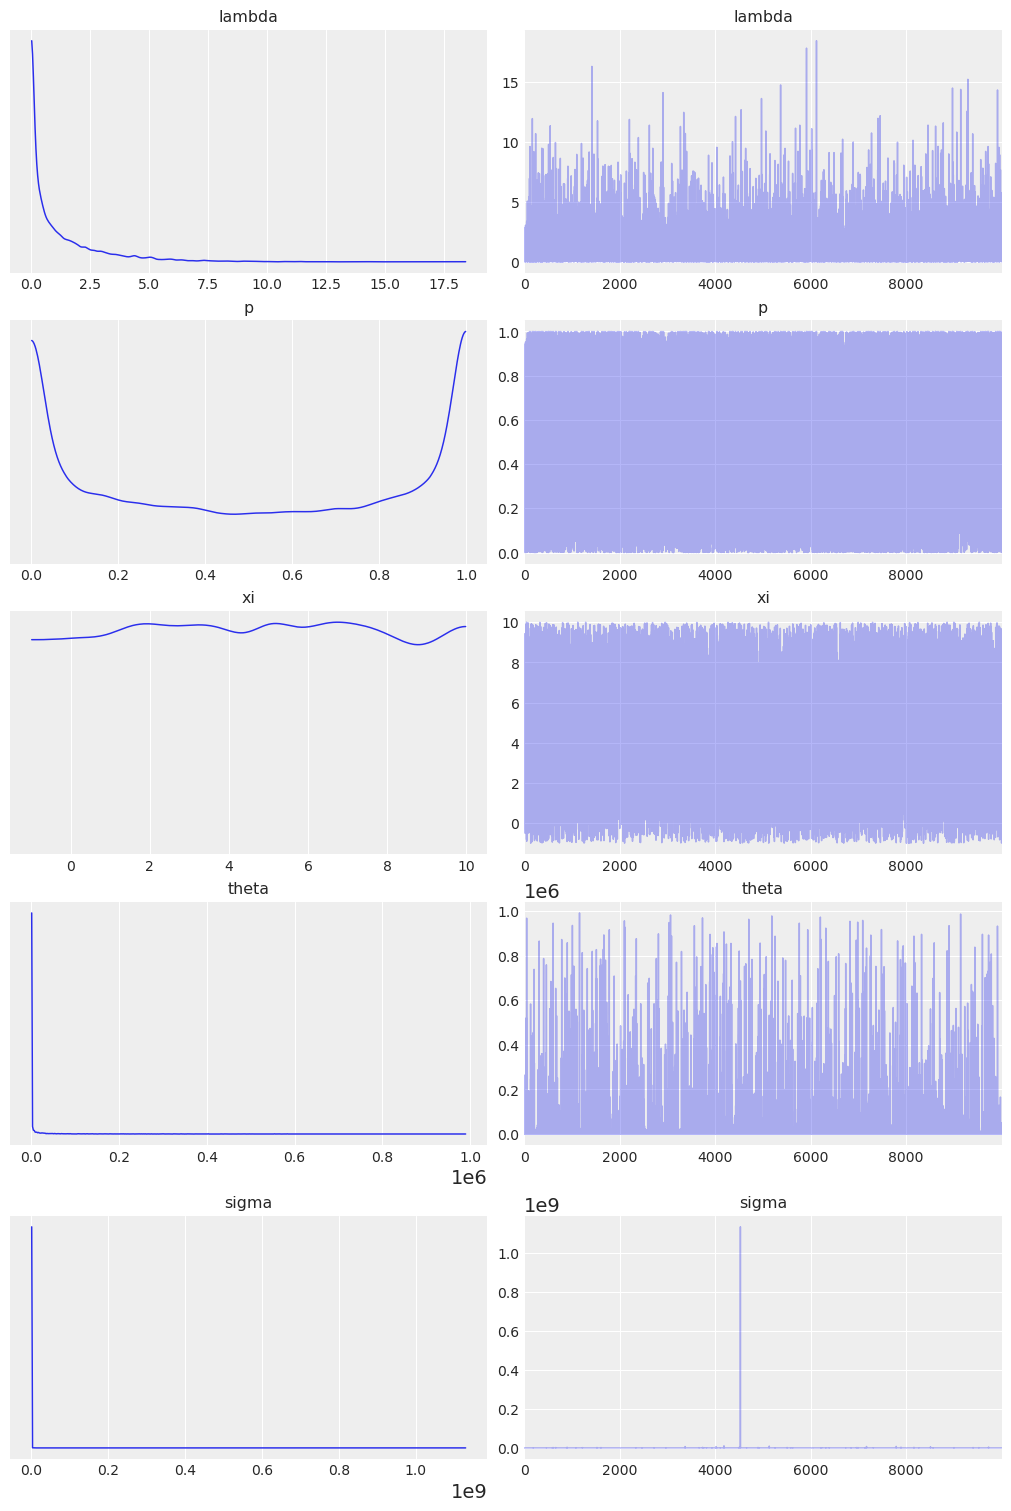

In [10]:
az.plot_trace(prior, compact=False, figsize=(10, 15), var_names=var_names)

In [11]:
threshold = 0.01

In [12]:
# Test effect of increasing number of draws
test_draws = [500, 1000, 2000, 4000, 10000]
test_results = []

# Fix parameters and sample size
lambda0, s0, xi0 = 0.05, 1.0, 0.3
n = 1000
rng = np.random.default_rng(23)

# Generate one dataset
x = rmix_gpd(n, lambda0, s0, xi0, threshold, rng)

for draws in tqdm(test_draws):
    with make_intensity_model(x, threshold):
        idata = pm.sample(draws=draws, tune=1000, chains=cores,
                          progressbar=False, random_seed=rng, var_names=var_names)
    
    # Extract posterior summaries
    post = az.summary(idata, var_names=['p', 'sigma', 'xi'])
    
    # Extract point estimates and HDIs
    p_mean = post.loc["p","mean"]
    p_hdi_l = post.loc["p","hdi_3%"]
    p_hdi_u = post.loc["p","hdi_97%"]
    
    sigma_mean = post.loc["sigma","mean"]
    sigma_hdi_l = post.loc["sigma","hdi_3%"]
    sigma_hdi_u = post.loc["sigma","hdi_97%"]
    
    xi_mean = post.loc["xi","mean"]
    xi_hdi_l = post.loc["xi","hdi_3%"]
    xi_hdi_u = post.loc["xi","hdi_97%"]
    
    test_results.append({
        "draws": draws,
        "p_true": 1 - np.exp(-lambda0),
        "p_hat": p_mean,
        "p_hdi_l": p_hdi_l,
        "p_hdi_u": p_hdi_u,
        "sigma_true": s0,
        "sigma_hat": sigma_mean, 
        "sigma_hdi_l": sigma_hdi_l,
        "sigma_hdi_u": sigma_hdi_u,
        "xi_true": xi0,
        "xi_hat": xi_mean,
        "xi_hdi_l": xi_hdi_l,
        "xi_hdi_u": xi_hdi_u
    })

# Convert to dataframe for analysis
draws_df = pd.DataFrame(test_results)

  0%|          | 0/5 [00:00<?, ?it/s]

Initializing NUTS using jitter+adapt_diag...


KeyboardInterrupt: 

In [ ]:
# Create figure with subplots for each parameter
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 12))

# Plot for p (probability)
ax1.axhline(draws_df['p_true'].iloc[0], color='r', linestyle='--', label='True value')
ax1.errorbar(range(len(draws_df)), draws_df['p_hat'], 
            yerr=[draws_df['p_hat'] - draws_df['p_hdi_l'], 
                  draws_df['p_hdi_u'] - draws_df['p_hat']], 
            fmt='o', capsize=5, label='Posterior estimate with HDI')

# Add prior distribution for p
prior_p = prior['p'].values.flatten()
# prior_p needs to be reshaped to 2D array for violinplot
# violinplot expects a list of 1D arrays, not a 2D array
ax1.violinplot([prior_p], [-0.5], points=100, widths=0.5, showextrema=True)
ax1.text(-0.5, ax1.get_ylim()[0], 'Prior', ha='center')

ax1.set_xticks(range(len(draws_df)))
ax1.set_xticklabels(draws_df['draws'])
ax1.set_xlabel('Number of draws')
ax1.set_ylabel('Arrival probability')
ax1.set_title('Arrival probabiltiy estimates vs number of draws')

# Plot for sigma
ax2.axhline(draws_df['sigma_true'].iloc[0], color='r', linestyle='--', label='True value')
ax2.errorbar(range(len(draws_df)), draws_df['sigma_hat'],
            yerr=[draws_df['sigma_hat'] - draws_df['sigma_hdi_l'],
                  draws_df['sigma_hdi_u'] - draws_df['sigma_hat']],
            fmt='o', capsize=5, label='Posterior estimate with HDI')

# Add prior distribution for sigma
prior_sigma = prior['sigma'].values.flatten()
ax2.violinplot([prior_sigma], [-0.5], points=100, widths=0.5)
ax2.text(-0.5, ax2.get_ylim()[0], 'Prior', ha='center')

ax2.set_xticks(range(len(draws_df)))
ax2.set_xticklabels(draws_df['draws'])
ax2.set_xlabel('Number of draws')
ax2.set_ylabel('Sigma')
ax2.set_title('Sigma estimates vs number of draws')

# Plot for xi
ax3.axhline(draws_df['xi_true'].iloc[0], color='r', linestyle='--', label='True value')
ax3.errorbar(range(len(draws_df)), draws_df['xi_hat'],
            yerr=[draws_df['xi_hat'] - draws_df['xi_hdi_l'],
                  draws_df['xi_hdi_u'] - draws_df['xi_hat']],
            fmt='o', capsize=5, label='Posterior estimate with HDI')

# Add prior distribution for xi
prior_xi = prior['xi'].values.flatten()
ax3.violinplot([prior_xi], [-0.5], points=100, widths=0.5)
ax3.text(-0.5, ax3.get_ylim()[0], 'Prior', ha='center')

ax3.set_xticks(range(len(draws_df)))
ax3.set_xticklabels(draws_df['draws'])
ax3.set_xlabel('Number of draws')
ax3.set_ylabel('Xi')
ax3.set_title('Xi estimates vs number of draws')

# Add legend outside of figure
for ax in [ax1, ax2, ax3]:
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [13]:
class LogNormalBayesianUpdater:
    def __init__(self, prior_type='reference', mu0=0, kappa0=0.01, alpha0=1.1, beta0=1):
        """
        Initialize the Bayesian updater.
        
        prior_type: 'reference' or 'NIG' (Normal-Inverse-Gamma)
        mu0, kappa0, alpha0, beta0: Hyperparameters for NIG prior
        """
        if prior_type not in ['reference', 'NIG']:
            raise ValueError("prior_type must be either 'reference' or 'NIG'")
        self.prior_type = prior_type
        self.mu0 = mu0
        self.kappa0 = kappa0
        self.alpha0 = alpha0
        self.beta0 = beta0

    def update(self, X):
        """
        Update posterior given observed data X (lognormal data).
        """
        self.X = X
        self.Y = np.log(X)  # work on log scale
        self.n = len(X)
        self.y_bar = np.mean(self.Y)
        self.S = np.sum((self.Y - self.y_bar) ** 2)

        if self.prior_type == 'NIG':
            self.kappa_n = self.kappa0 + self.n
            self.mu_n = (self.kappa0 * self.mu0 + self.n * self.y_bar) / self.kappa_n
            self.alpha_n = self.alpha0 + self.n / 2
            self.beta_n = (self.beta0 + 0.5 * self.S + 
                           0.5 * self.kappa0 * self.n * (self.y_bar - self.mu0)**2 / self.kappa_n)
        elif self.prior_type == 'reference':
            self.kappa_n = self.n
            self.mu_n = self.y_bar
            self.alpha_n = (self.n - 1) / 2
            self.beta_n = self.S / 2

    def sample_posterior(self, n_samples=1000):
        """
        Sample (mu, sigma) from the posterior distribution.
        """
        sigma2_samples = scipy.stats.invgamma.rvs(a=self.alpha_n, scale=self.beta_n, size=n_samples)
        sigma_samples = np.sqrt(sigma2_samples)
        mu_samples = scipy.stats.norm.rvs(loc=self.mu_n, scale=np.sqrt(sigma2_samples / self.kappa_n))
        return mu_samples, sigma_samples
    
    def plot_prior_samples(self, n_samples=500, ax=None):
        """
        Plot samples from the prior distribution.
        
        Parameters
        ----------
        n_samples : int, optional
            Number of samples to draw from prior, by default 500
        ax : matplotlib.axes.Axes, optional
            Axes to plot on. If None, creates new figure, by default None
        """
        if self.prior_type == 'reference':
            print("Reference prior is improper (only defined up to proportionality). Skipping prior samples.")
            return

        sigma2_samples = scipy.stats.invgamma.rvs(a=self.alpha0, scale=self.beta0, size=n_samples)
        sigma_samples = np.sqrt(sigma2_samples)
        mu_samples = scipy.stats.norm.rvs(loc=self.mu0, scale=np.sqrt(sigma2_samples / self.kappa0))

        if ax is None:
            fig, ax = plt.subplots(figsize=(6,4))
            
        ax.scatter(mu_samples, sigma_samples, alpha=0.5)
        ax.set_xlabel(r"$\mu$")
        ax.set_ylabel(r"$\sigma$")
        ax.set_title("Prior Samples")
        ax.grid(True)
        
        if ax is None:
            plt.show()

    def plot_posterior_samples(self, n_samples=500, ax=None):
        """
        Plot samples from the posterior distribution.
        
        Parameters
        ----------
        n_samples : int, optional
            Number of samples to draw from posterior, by default 500
        ax : matplotlib.axes.Axes, optional
            Axes to plot on. If None, creates new figure, by default None
        """
        mu_samples, sigma_samples = self.sample_posterior(n_samples)

        if ax is None:
            fig, ax = plt.subplots(figsize=(6,4))
            
        ax.scatter(mu_samples, sigma_samples, alpha=0.5)
        ax.set_xlabel(r"$\mu$")
        ax.set_ylabel(r"$\sigma$")
        ax.set_title("Posterior samples")
        ax.grid(True)
        
        if ax is None:
            plt.show()
            
    def get_prior_grid(self, mu_range=None, sigma_range=None, n_points=50):
        """
        Calculate the analytical prior probability density function on a grid.
        
        Parameters
        ----------
        mu_range : tuple, optional
            Range of mu values (min, max). If None, determined automatically.
        sigma_range : tuple, optional
            Range of sigma values (min, max). If None, determined automatically.
        n_points : int, optional
            Number of points to use in each dimension, by default 50
            
        Returns
        -------
        dict
            Dictionary containing grid points and density values:
            - 'mu_grid': 2D array of mu values
            - 'sigma_grid': 2D array of sigma values 
            - 'density': 2D array of density values
        """
        if self.prior_type == 'reference':
            print("Reference prior is improper. Cannot calculate analytical PDF.")
            return None
        
        # Generate grid of points
        if mu_range is None:
            mu_range = (self.mu0 - 3 * np.sqrt(self.beta0 / (self.alpha0 * self.kappa0)), 
                        self.mu0 + 3 * np.sqrt(self.beta0 / (self.alpha0 * self.kappa0)))
        
        if sigma_range is None:
            mode_sigma = np.sqrt(self.beta0 / (self.alpha0 + 1))  # Mode of inverse gamma
            sigma_range = (mode_sigma / 3, mode_sigma * 3)
        
        mu_grid = np.linspace(mu_range[0], mu_range[1], n_points)
        sigma_grid = np.linspace(sigma_range[0], sigma_range[1], n_points)
        MU, SIGMA = np.meshgrid(mu_grid, sigma_grid)
        
        # Calculate prior density
        SIGMA2 = SIGMA**2
        prior_density = np.zeros_like(MU)
        
        # p(mu, sigma²) = p(mu|sigma²) * p(sigma²)
        # p(mu|sigma²) = Normal(mu0, sigma²/kappa0)
        # p(sigma²) = InvGamma(alpha0, beta0)
        for i in range(n_points):
            for j in range(n_points):
                mu_density = scipy.stats.norm.pdf(MU[i,j], loc=self.mu0, scale=np.sqrt(SIGMA2[i,j] / self.kappa0))
                sigma2_density = scipy.stats.invgamma.pdf(SIGMA2[i,j], a=self.alpha0, scale=self.beta0)
                prior_density[i,j] = mu_density * sigma2_density
                
        return pd.DataFrame({
            'mu': MU.flatten(),
            'sigma': SIGMA.flatten(),
            'density': prior_density.flatten()
        })

    def get_posterior_grid(self, mu_range=None, sigma_range=None, n_points=50):
        """
        Calculate the analytical posterior probability density function on a grid.
        
        Parameters
        ----------
        mu_range : tuple, optional
            Range of mu values (min, max). If None, determined automatically.
        sigma_range : tuple, optional
            Range of sigma values (min, max). If None, determined automatically.
        n_points : int, optional
            Number of points to use in each dimension, by default 50
            
        Returns
        -------
        dict
            Dictionary containing grid points and density values:
            - 'mu_grid': 2D array of mu values
            - 'sigma_grid': 2D array of sigma values
            - 'density': 2D array of density values
        """
        # Generate grid of points
        if mu_range is None:
            mu_range = (self.mu_n - 3 * np.sqrt(self.beta_n / (self.alpha_n * self.kappa_n)), 
                        self.mu_n + 3 * np.sqrt(self.beta_n / (self.alpha_n * self.kappa_n)))
        
        if sigma_range is None:
            mode_sigma = np.sqrt(self.beta_n / (self.alpha_n + 1))  # Mode of inverse gamma
            sigma_range = (mode_sigma / 3, mode_sigma * 3)
        
        mu_grid = np.linspace(mu_range[0], mu_range[1], n_points)
        sigma_grid = np.linspace(sigma_range[0], sigma_range[1], n_points)
        MU, SIGMA = np.meshgrid(mu_grid, sigma_grid)
        
        # Calculate posterior density
        SIGMA2 = SIGMA**2
        posterior_density = np.zeros_like(MU)
        
        # p(mu, sigma²|data) = p(mu|sigma², data) * p(sigma²|data)
        # p(mu|sigma², data) = Normal(mu_n, sigma²/kappa_n)
        # p(sigma²|data) = InvGamma(alpha_n, beta_n)
        for i in range(n_points):
            for j in range(n_points):
                mu_density = scipy.stats.norm.pdf(MU[i,j], loc=self.mu_n, scale=np.sqrt(SIGMA2[i,j] / self.kappa_n))
                sigma2_density = scipy.stats.invgamma.pdf(SIGMA2[i,j], a=self.alpha_n, scale=self.beta_n)
                posterior_density[i,j] = mu_density * sigma2_density
                
        return pd.DataFrame({
            'mu': MU.flatten(),
            'sigma': SIGMA.flatten(),
            'density': posterior_density.flatten()
        })
        
    def plot_density_grid(self, grid_df, ax=None, cmap="Blues", label="Density"):
        """
        Plot a density grid using seaborn's kdeplot.
        
        Parameters
        ----------
        grid_df : DataFrame
            Dictionary containing grid points and density values from get_prior_grid or get_posterior_grid
        ax : matplotlib.axes.Axes, optional
            Axes to plot on. If None, creates new figure
        cmap : str, optional
            Colormap to use for the plot, by default "Blues"
        label : str, optional
            Label for the plot, by default "Density"
        
        Returns
        -------
        pandas.DataFrame
            DataFrame containing the flattened grid data
        """
        if grid_df is None:
            return None
            
        if ax is None:
            fig, ax = plt.subplots(figsize=(6,4))
            
        # Convert grid data to format suitable for seaborn
        mu_flat = grid_df['mu_grid']
        sigma_flat = grid_df['sigma_grid']
        density_flat = grid_df['density']
        
        # Create a DataFrame
        df = pd.DataFrame({
            'mu': mu_flat,
            'sigma': sigma_flat,
            'density': density_flat,
            'type': label
        })
        
        # Plot using seaborn's kdeplot
        sns.kdeplot(
            x=mu_flat,
            y=sigma_flat,
            weights=density_flat,
            cmap=cmap,
            fill=True,
            levels=20,
            ax=ax,
            label=label
        )
        
        ax.set_xlabel(r"$\mu$")
        ax.set_ylabel(r"$\sigma$")
        ax.set_title("Density")
        
        # Add a colorbar
        norm = plt.Normalize(density_flat.min(), density_flat.max())
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        plt.colorbar(sm, ax=ax, label="Density")
        
        if ax is None:
            plt.show()
            
        return df


In [14]:
final_allrisk_ds = pd.read_csv("../../data/clean/final_allrisk_ds.csv")

In [15]:
duration_data = final_allrisk_ds['duration']

C:\Users\squaade\AppData\Local\Temp\ipykernel_10320\3510262522.py:107: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


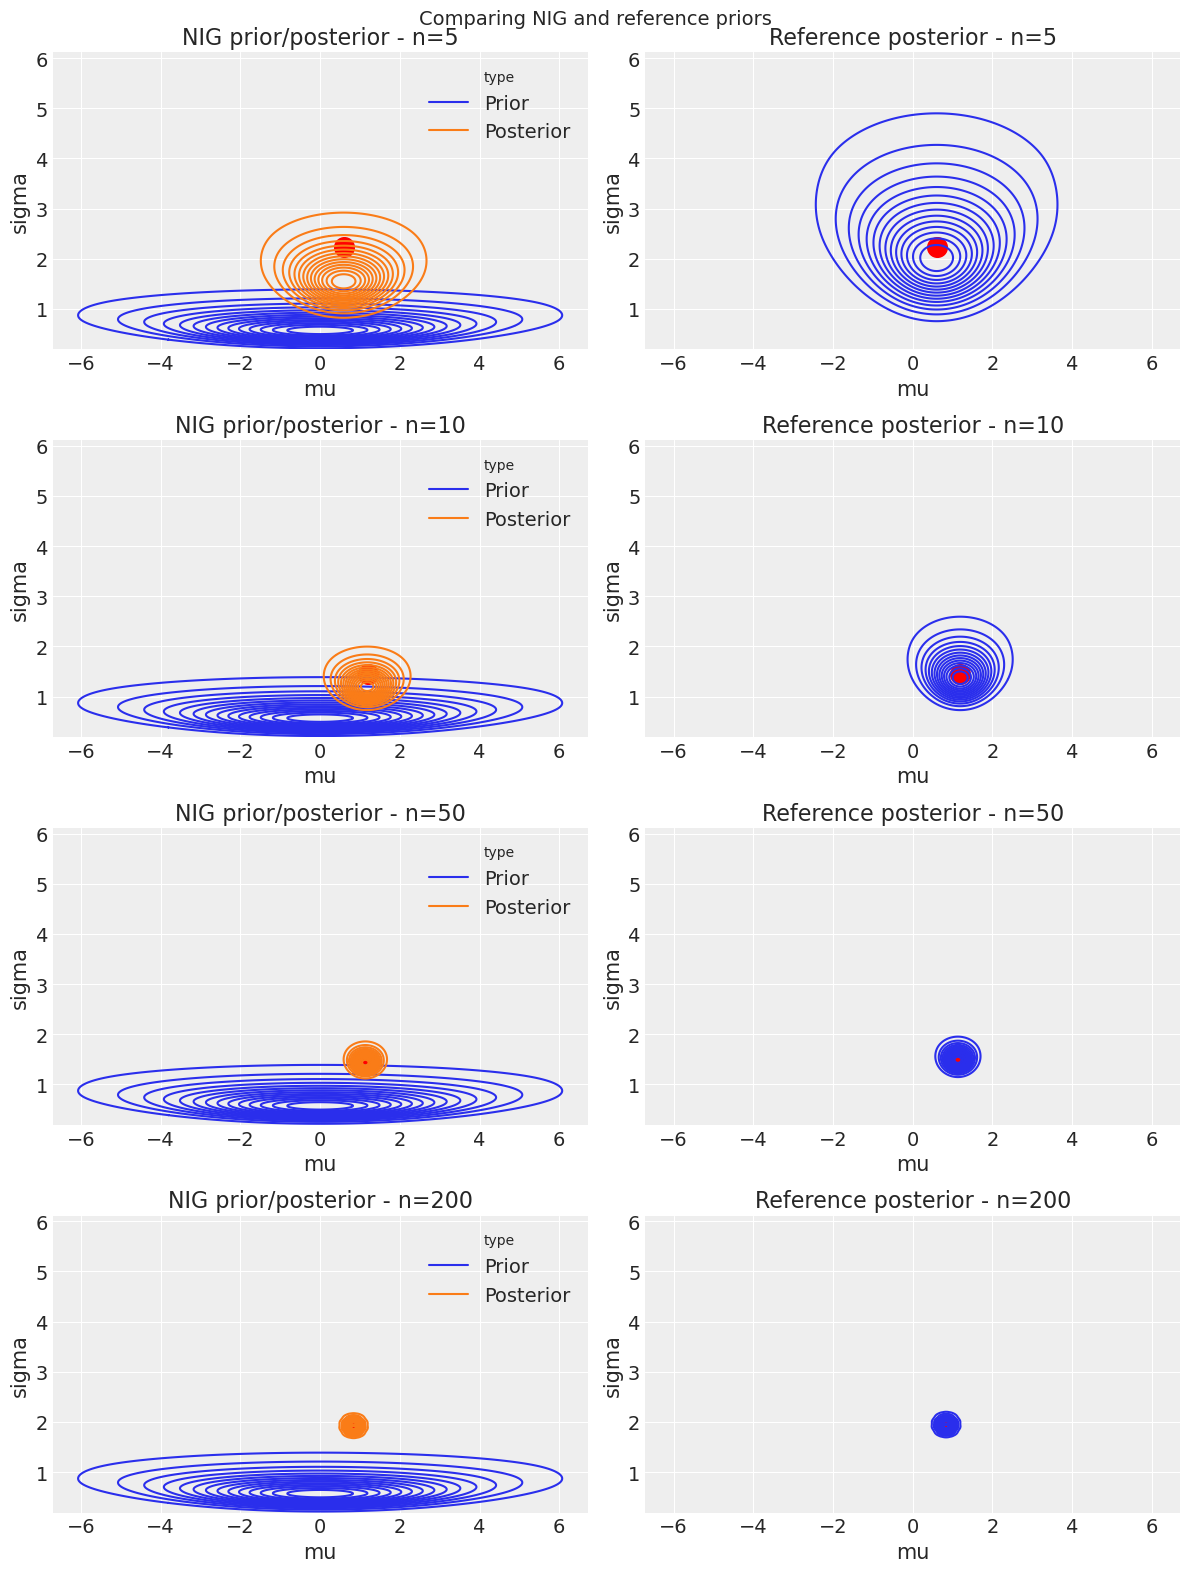

In [16]:
# Generate a few small datasets of different sizes
rng = np.random.default_rng(42)
datasets = {
    'n=5': rng.lognormal(1, 2, size=5),
    'n=10': rng.lognormal(1, 2, size=10),
    'n=50': rng.lognormal(1, 2, size=50),
    'n=200': rng.lognormal(1, 2, size=200)
}

# Create figure with subplots for each dataset
fig, axes = plt.subplots(len(datasets), 2, figsize=(12, 4*len(datasets)))
fig.suptitle('Comparing NIG and reference priors', fontsize=14)

# Create NIG prior once to ensure consistency
nig_prior = LogNormalBayesianUpdater(prior_type='NIG', mu0=0, kappa0=0.1, alpha0=2, beta0=1)
prior_df = nig_prior.get_prior_grid()
prior_df['type'] = 'Prior'

# Track min/max values to set consistent axes
mu_min, mu_max = float('inf'), float('-inf')
sigma_min, sigma_max = float('inf'), float('-inf')

# First pass to get axis limits
for name, data in datasets.items():
    true_mu = np.log(data).mean()
    true_sigma = np.log(data).std()
    
    nig_updater = LogNormalBayesianUpdater(prior_type='NIG', mu0=0, kappa0=0.1, alpha0=2, beta0=1)
    nig_updater.update(data)
    ref_updater = LogNormalBayesianUpdater(prior_type='reference')
    ref_updater.update(data)
    
    # Get grids
    post_nig_df = nig_updater.get_posterior_grid()
    post_ref_df = ref_updater.get_posterior_grid()
    
    # Update min/max
    mu_min = min(mu_min, prior_df['mu'].min(), post_nig_df['mu'].min(), post_ref_df['mu'].min())
    mu_max = max(mu_max, prior_df['mu'].max(), post_nig_df['mu'].max(), post_ref_df['mu'].max())
    sigma_min = min(sigma_min, prior_df['sigma'].min(), post_nig_df['sigma'].min(), post_ref_df['sigma'].min())
    sigma_max = max(sigma_max, prior_df['sigma'].max(), post_nig_df['sigma'].max(), post_ref_df['sigma'].max())

# Second pass to plot with consistent axes
for i, (name, data) in enumerate(datasets.items()):
    # Get true parameters for this dataset
    true_mu = np.log(data).mean()
    true_sigma = np.log(data).std()
    
    # NIG prior/posterior
    nig_updater = LogNormalBayesianUpdater(prior_type='NIG', mu0=0, kappa0=0.1, alpha0=2, beta0=1)
    nig_updater.update(data)
    
    # Reference prior
    ref_updater = LogNormalBayesianUpdater(prior_type='reference')
    ref_updater.update(data)
    
    # Plot NIG prior/posterior PDFs
    ax = axes[i,0]
    post_df = nig_updater.get_posterior_grid()
    post_df['type'] = 'Posterior'
    
    # Combine prior and posterior data
    combined_df = pd.concat([prior_df, post_df])
    
    # Plot with consistent KDE parameters
    sns.kdeplot(
        data=combined_df,
        x='mu',
        y='sigma', 
        weights='density',
        hue='type',
        fill=False,
        levels=15,
        common_norm=False,
        ax=ax,
        bw_adjust=1.0,  # Consistent bandwidth
        cut=0  # Don't extend beyond data range
    )
    
    # Add true value point
    ax.scatter(true_mu, true_sigma, color='red', s=200, label='True value')
    ax.set_title(f'NIG prior/posterior - {name}')
    ax.set_xlim(mu_min, mu_max)
    ax.set_ylim(sigma_min, sigma_max)
    
    # Plot reference posterior PDF
    ax = axes[i,1]
    post_df = ref_updater.get_posterior_grid()
    sns.kdeplot(
        data=post_df,
        x='mu',
        y='sigma',
        weights='density',
        fill=False,
        levels=15,
        ax=ax,
        bw_adjust=1.0,  # Consistent bandwidth
        cut=0  # Don't extend beyond data range
    )
    
    # Add true value point
    ax.scatter(true_mu, true_sigma, color='red', s=200, label='True value')
    ax.set_title(f'Reference posterior - {name}')
    ax.set_xlim(mu_min, mu_max)
    ax.set_ylim(sigma_min, sigma_max)

plt.tight_layout()
plt.show()

It looks to me like we should definitely specify a prior. So let's convert the lognormal parameters into some expectations and roughly tether to expert survey.

We consider the prior with `mu = 0.493` and `sigma = 1.099` as this produces a mean of about three years and a less than one in twenty chance of getting a pandemic longer than ten years. We then consider how to calibrate `k_0, alpha_0 and beta_0`.

In [17]:
def calibrate_lognormal_prior(mean_target, tail_target_value, tail_target_prob):
    """Calibrate (mu, sigma) for a lognormal to match mean and upper tail probability."""
    def equations(vars):
        mu, sigma = vars
        eq1 = np.exp(mu + sigma**2 / 2) - mean_target
        eq2 = 1 - scipy.stats.norm.cdf((np.log(tail_target_value) - mu) / sigma) - tail_target_prob
        return [eq1, eq2]

    mu_init = np.log(mean_target)
    sigma_init = 1.0
    mu, sigma = scipy.optimize.fsolve(equations, [mu_init, sigma_init])
    return mu, sigma

# Example usage
mu, sigma = calibrate_lognormal_prior(mean_target=3, tail_target_value=10, tail_target_prob=0.05)
print(f"Calibrated LogNormal parameters: mu = {mu:.4f}, sigma = {sigma:.4f}")

# -------------------------------------------
# Normal-Inverse-Gamma calibration

def calibrate_nig_prior(mu_target, sigma_target, kappa0=1):
    """Given target mu and sigma for prior, set NIG hyperparameters."""
    mu0 = mu_target
    alpha0 = 2  # Minimal informative prior for sigma^2 (mean exists)
    beta0 = (alpha0 - 1) * sigma_target**2
    return mu0, kappa0, alpha0, beta0

# Example usage
mu0, kappa0, alpha0, beta0 = calibrate_nig_prior(mu_target=mu, sigma_target=sigma)
print(f"Calibrated NIG parameters: mu0 = {mu0:.4f}, kappa0 = {kappa0}, alpha0 = {alpha0}, beta0 = {beta0:.4f}")

Calibrated LogNormal parameters: mu = 0.4944, sigma = 1.0993
Calibrated NIG parameters: mu0 = 0.4944, kappa0 = 1, alpha0 = 2, beta0 = 1.2085


C:\Users\squaade\AppData\Local\Temp\ipykernel_10320\984457289.py:86: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


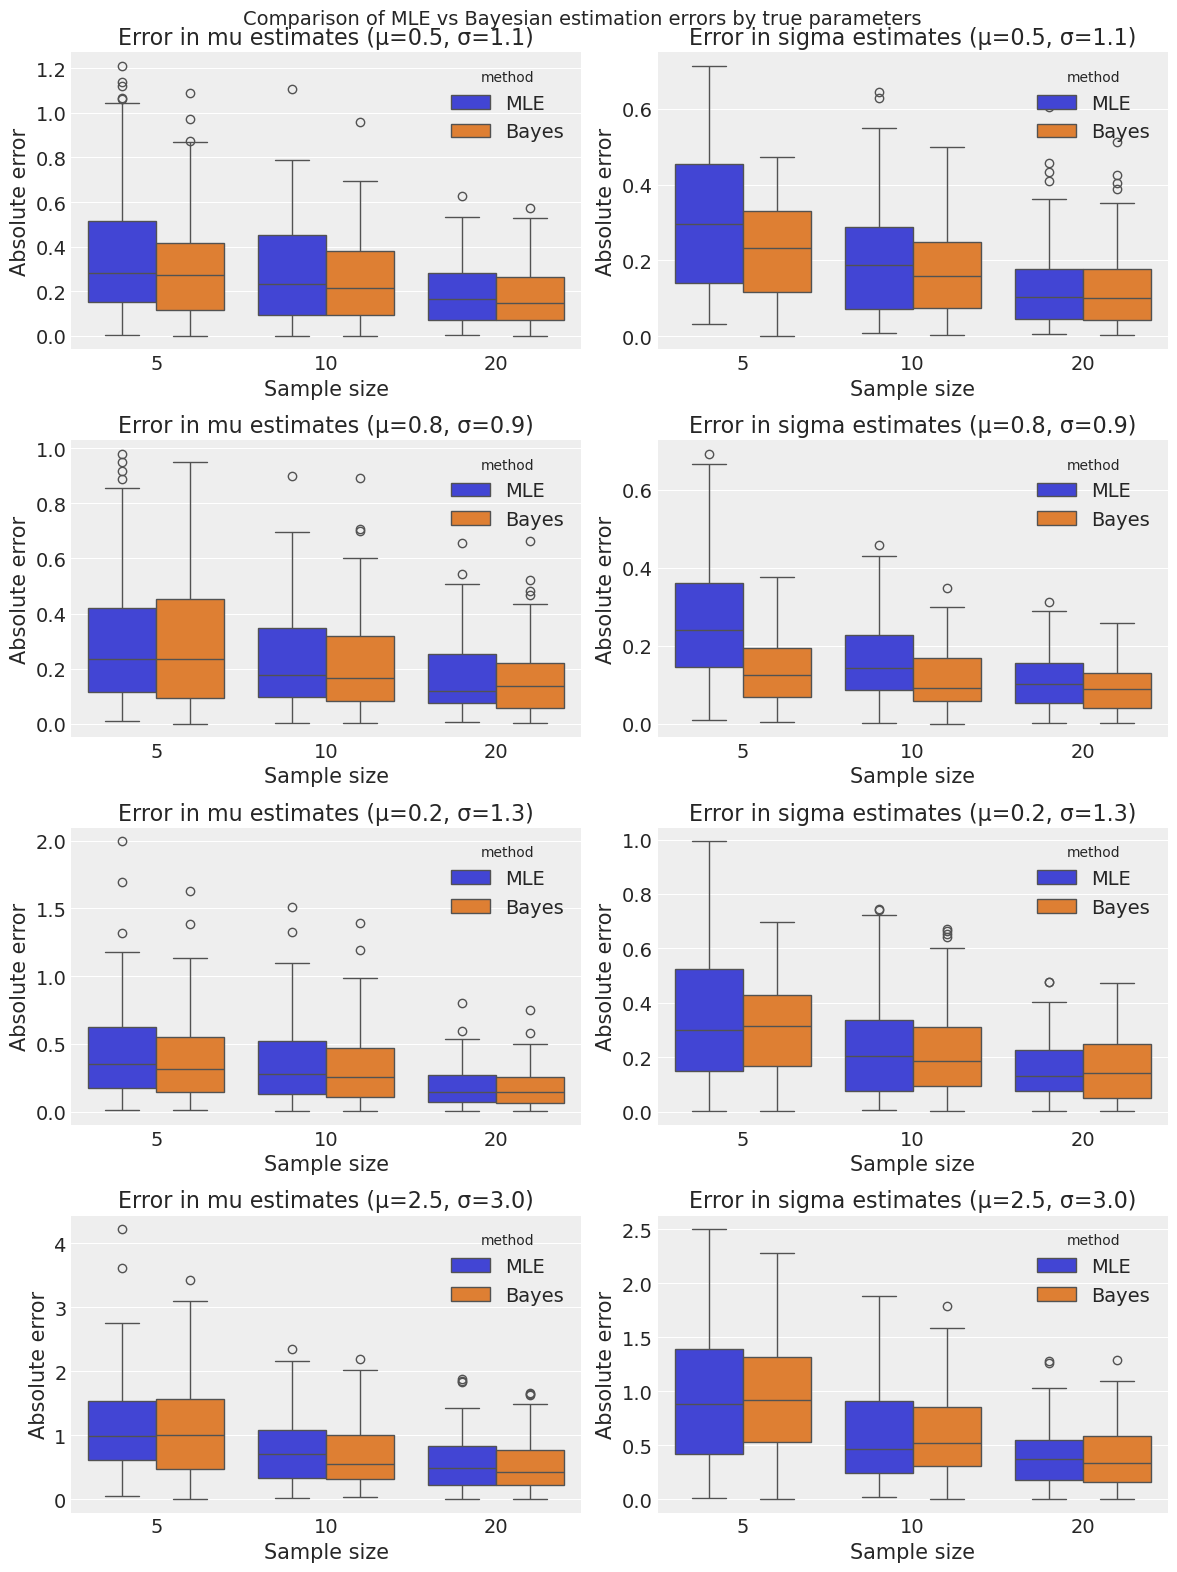

In [44]:
# Run experiments comparing MLE vs Bayesian estimation
np.random.seed(42)
n_experiments = 100
sample_sizes = [5, 10, 20]
# Test across different true parameter combinations
true_params = [
    (0.493, 1.099),  # Original calibrated values
    (0.8, 0.9),      # Higher mean, lower variance
    (0.2, 1.3),      # Lower mean, higher variance
    (2.5, 3)
]

results = {
    'sample_size': [],
    'method': [],
    'true_mu': [],
    'true_sigma': [],
    'mu_est': [],
    'sigma_est': [],
    'mu_error': [],
    'sigma_error': []
}

for true_mu, true_sigma in true_params:
    for n in sample_sizes:
        for i in range(n_experiments):
            # Generate sample from true lognormal
            sample = np.random.lognormal(true_mu, true_sigma, size=n)
            
            # MLE estimation
            mle_sigma, _, mle_scale = scipy.stats.lognorm.fit(sample, floc=0)
            mle_mu = np.log(mle_scale) # Convert from scale to mu
            
            # Bayesian estimation with NIG prior
            # Use misspecified prior parameters to test robustness
            mu0, kappa0, alpha0, beta0 = calibrate_nig_prior(mu_target=0, sigma_target=1)
            
            n_data = len(sample)
            xbar = np.mean(np.log(sample))
            s2 = np.var(np.log(sample))
            
            # Posterior parameters
            kappa_n = kappa0 + n_data
            mu_n = (kappa0 * mu0 + n_data * xbar) / kappa_n
            alpha_n = alpha0 + n_data/2
            beta_n = beta0 + 0.5 * ((n_data - 1)*s2 + 
                                   (n_data * kappa0 * (xbar - mu0)**2) / kappa_n)
            
            # Store results
            results['sample_size'].extend([n, n])
            results['method'].extend(['MLE', 'Bayes'])
            results['true_mu'].extend([true_mu, true_mu])
            results['true_sigma'].extend([true_sigma, true_sigma])
            results['mu_est'].extend([mle_mu, mu_n])
            results['sigma_est'].extend([mle_sigma, np.sqrt(beta_n/(alpha_n-1))])
            results['mu_error'].extend([abs(mle_mu - true_mu), abs(mu_n - true_mu)])
            results['sigma_error'].extend([abs(mle_sigma - true_sigma), 
                                         abs(np.sqrt(beta_n/(alpha_n-1)) - true_sigma)])
# Convert to DataFrame for analysis and create plots
results_df = pd.DataFrame(results)

# Create figure with subplots for different parameter combinations
unique_params = list(zip(results_df['true_mu'].unique(), results_df['true_sigma'].unique()))
n_params = len(unique_params)
fig, axes = plt.subplots(n_params, 2, figsize=(12, 4*n_params))
fig.suptitle('Comparison of MLE vs Bayesian estimation errors by true parameters', fontsize=14)

for i, (true_mu, true_sigma) in enumerate(unique_params):
    param_data = results_df[
        (results_df['true_mu'] == true_mu) & 
        (results_df['true_sigma'] == true_sigma)
    ]
    
    # Plot mu errors
    sns.boxplot(data=param_data, x='sample_size', y='mu_error', hue='method', ax=axes[i,0])
    axes[i,0].set_title(f'Error in mu estimates (μ={true_mu:.1f}, σ={true_sigma:.1f})')
    axes[i,0].set_xlabel('Sample size')
    axes[i,0].set_ylabel('Absolute error')

    # Plot sigma errors
    sns.boxplot(data=param_data, x='sample_size', y='sigma_error', hue='method', ax=axes[i,1])
    axes[i,1].set_title(f'Error in sigma estimates (μ={true_mu:.1f}, σ={true_sigma:.1f})')
    axes[i,1].set_xlabel('Sample size')
    axes[i,1].set_ylabel('Absolute error')

plt.tight_layout()

In [32]:
results_df

,sample_size,method,mu_est,sigma_est,mu_error,sigma_error
0,5,MLE,0.997444,0.696175,0.504444,0.402825
1,5,Bayes,0.913370,0.807668,0.420370,0.291332
2,5,MLE,0.973394,0.807163,0.480394,0.291837
3,5,Bayes,0.893328,0.863048,0.400328,0.235952
4,5,MLE,-0.457719,0.904177,0.950719,0.194823
...,...,...,...,...,...,...
115,20,Bayes,0.547549,1.206261,0.054549,0.107261
116,20,MLE,0.301148,1.273842,0.191852,0.174842
117,20,Bayes,0.310284,1.229957,0.182716,0.130957
118,20,MLE,0.494064,0.823989,0.001064,0.275011


C:\Users\squaade\AppData\Local\Temp\ipykernel_10320\605281668.py:89: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


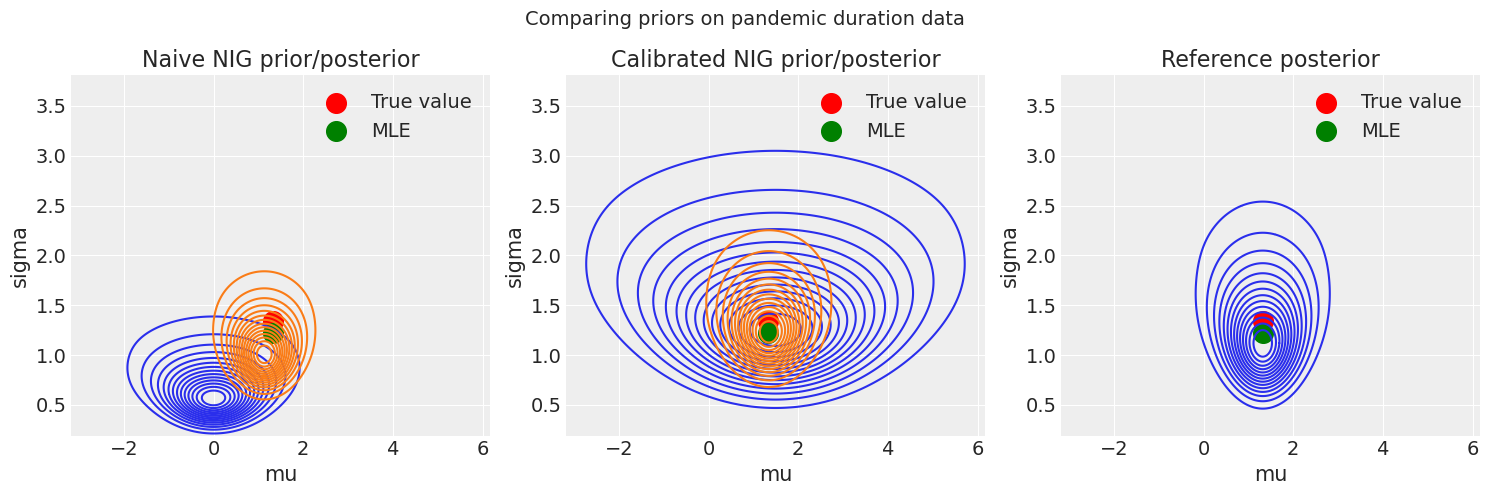

In [37]:
# Create figure with subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Comparing priors on pandemic duration data', fontsize=14)

# Get true parameters from data
true_mu = np.log(duration_data).mean()
true_sigma = np.log(duration_data).std()

# 1. Naive NIG prior
naive_updater = LogNormalBayesianUpdater(prior_type='NIG', mu0=0, kappa0=1, alpha0=2, beta0=1)
naive_updater.update(duration_data)
naive_prior = naive_updater.get_prior_grid()
naive_post = naive_updater.get_posterior_grid()
naive_prior['type'] = 'Prior'
naive_post['type'] = 'Posterior'
naive_df = pd.concat([naive_prior, naive_post])

# 2. Calibrated NIG prior using parameters from above
cal_updater = LogNormalBayesianUpdater(prior_type='NIG', mu0=mu0, kappa0=kappa0, alpha0=alpha0, beta0=beta0)
cal_updater.update(duration_data)
cal_prior = cal_updater.get_prior_grid()
cal_post = cal_updater.get_posterior_grid()
cal_prior['type'] = 'Prior'
cal_post['type'] = 'Posterior'
cal_df = pd.concat([cal_prior, cal_post])

# 3. Reference prior
ref_updater = LogNormalBayesianUpdater(prior_type='reference')
ref_updater.update(duration_data)
ref_post = ref_updater.get_posterior_grid()

# Plot results
titles = ['Naive NIG prior/posterior', 'Calibrated NIG prior/posterior', 'Reference posterior']
dfs = [naive_df, cal_df, ref_post]

# Get overall min/max for consistent axes
all_mu = pd.concat([df['mu'] for df in dfs])
all_sigma = pd.concat([df['sigma'] for df in dfs])
mu_min, mu_max = all_mu.min(), all_mu.max()
sigma_min, sigma_max = all_sigma.min(), all_sigma.max()

# Fit MLE lognormal
mle_params = scipy.stats.lognorm.fit(duration_data, floc=0)
mle_sigma, _, mle_mu = mle_params  # fit returns (s, loc, scale)
mle_mu = np.log(mle_mu)  # Convert scale to mu

for i, (title, df) in enumerate(zip(titles, dfs)):
    ax = axes[i]
    if i < 2:  # For NIG priors
        sns.kdeplot(
            data=df,
            x='mu',
            y='sigma', 
            weights='density',
            hue='type',
            fill=False,
            levels=15,
            common_norm=False,
            ax=ax,
            bw_adjust=1.0,
            cut=0
        )
    else:  # For reference prior
        sns.kdeplot(
            data=df,
            x='mu',
            y='sigma',
            weights='density', 
            fill=False,
            levels=15,
            ax=ax,
            bw_adjust=1.0,
            cut=0
        )
    
    # Add true value point
    ax.scatter(true_mu, true_sigma, color='red', s=200, label='True value')
    ax.scatter(mle_mu, mle_sigma, color='green', s=200, label='MLE')
    
    ax.set_title(title)
    
    # Set consistent axis limits
    ax.set_xlim(mu_min, mu_max)
    ax.set_ylim(sigma_min, sigma_max)
    
    # Add legend
    ax.legend()

plt.tight_layout()
plt.show()

C:\Users\squaade\AppData\Local\Temp\ipykernel_10320\4188329431.py:39: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


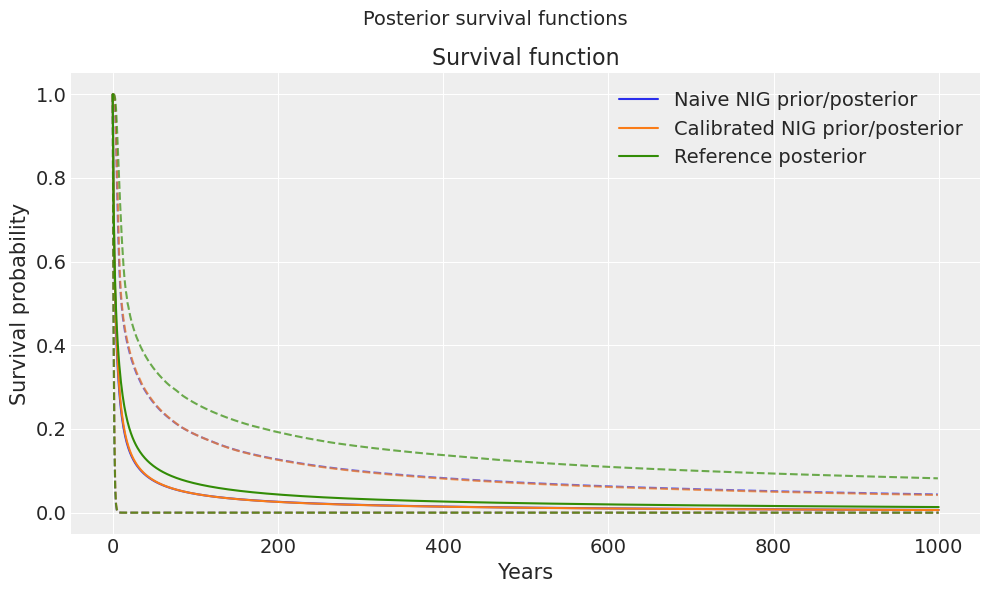

In [24]:
# Create figure with single plot for survival functions
fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle('Posterior survival functions', fontsize=14)

# Create time points for survival function
t = np.linspace(0, 1000, 1000)

# Plot survival function for each prior type
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
for (df, title), color in zip(zip(dfs, titles), colors):
    if 'type' in df.columns:
        # For NIG priors, use only posterior samples
        posterior_df = df[df['type'] == 'Posterior']
    else:
        # For reference prior, use all samples
        posterior_df = df
        
    # Calculate survival function for each posterior sample
    survival_curves = np.zeros((len(posterior_df), len(t)))
    for i, (mu, sigma) in enumerate(zip(posterior_df['mu'], posterior_df['sigma'])):
        survival_curves[i] = 1 - scipy.stats.lognorm.cdf(t, s=sigma, scale=np.exp(mu))
    
    # Calculate mean and percentiles
    mean_survival = np.mean(survival_curves, axis=0)
    lower = np.percentile(survival_curves, 2.5, axis=0)
    upper = np.percentile(survival_curves, 97.5, axis=0)
    
    # Plot mean and credible interval
    ax.plot(t, mean_survival, label=title, color=color)
    ax.plot(t, lower, upper, alpha=0.7, color=color, linestyle='--')

# Customize plot
ax.set_title('Survival function')
ax.set_xlabel('Years')
ax.set_ylabel('Survival probability')
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()


Calibrated prior actually appears to be wider. We could assume that experiment with the effects of a bigger kappa_0. Something to outline to Chris.
- Also add MLE to these plots.

### Pandemic intensity

In [20]:
# ---- design grid ----
true_grid = list(product([0.1, 0.05], # lambda
                         [1.0, 2.0], # σ
                         [0.3, 1.2])) # ξ
sample_ns = [100, 200] # tiny samples
n_rep = 4 # repeats per cell
rng_master = np.random.default_rng(23)

results = []
for (lambda0, s0, xi0), n in tqdm(list(product(true_grid, sample_ns))):
    for rep in range(n_rep):
        x = rmix_gpd(n, lambda0, s0, xi0, threshold, rng_master)
        with make_intensity_model(x, threshold):
            idata = pm.sample(draws=1000, tune=1000, chains=cores,
                              progressbar=False, random_seed=rng_master)
        post = az.summary(idata, var_names=['log_lambda', 'log_sigma_raw', 'xi_raw'])
        
        # Calculate HDIs for all parameters
        p_mean = 1 - np.exp(-np.exp(post.loc["log_lambda","mean"]))
        p_hdi_l = 1 - np.exp(-np.exp(post.loc["log_lambda","hdi_3%"]))
        p_hdi_u = 1 - np.exp(-np.exp(post.loc["log_lambda","hdi_97%"]))
        
        sigma_mean = np.exp(post.loc["log_sigma_raw","mean"])
        sigma_hdi_l = np.exp(post.loc["log_sigma_raw","hdi_3%"])
        sigma_hdi_u = np.exp(post.loc["log_sigma_raw","hdi_97%"])
        
        xi_mean = post.loc["xi_raw","mean"]
        xi_hdi_l = post.loc["xi_raw","hdi_3%"]
        xi_hdi_u = post.loc["xi_raw","hdi_97%"]
        
        results.append({
            "lambda_true": lambda0,
            "p_true": 1 - np.exp(-lambda0),
            "sigma_true": s0, 
            "xi_true": xi0,
            "n": n,
            "p_hat": p_mean,
            "p_hdi_l": p_hdi_l,
            "p_hdi_u": p_hdi_u,
            "sigma_hat": sigma_mean,
            "sigma_hdi_l": sigma_hdi_l, 
            "sigma_hdi_u": sigma_hdi_u,
            "xi_hat": xi_mean,
            "xi_hdi_l": xi_hdi_l,
            "xi_hdi_u": xi_hdi_u,
            "sample_ns": n,
            "num_above_threshold": (x > threshold).sum()
        })

df = pd.DataFrame(results)
df.to_csv("sim_small_sample.csv", index=False)

  0%|          | 0/16 [00:00<?, ?it/s]

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [lambda, xi, theta]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 22 seconds.
There were 1375 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


KeyError: 'var names: "[\'log_lambda\' \'log_sigma_raw\' \'xi_raw\'] are not present" in dataset'

array([[<Axes: title={'center': 'log_lambda'}>,
        <Axes: title={'center': 'log_sigma_raw'}>,
        <Axes: title={'center': 'xi_raw'}>],
       [<Axes: title={'center': 'lambda'}>,
        <Axes: title={'center': 'p'}>,
        <Axes: title={'center': 'sigma_raw'}>]], dtype=object)

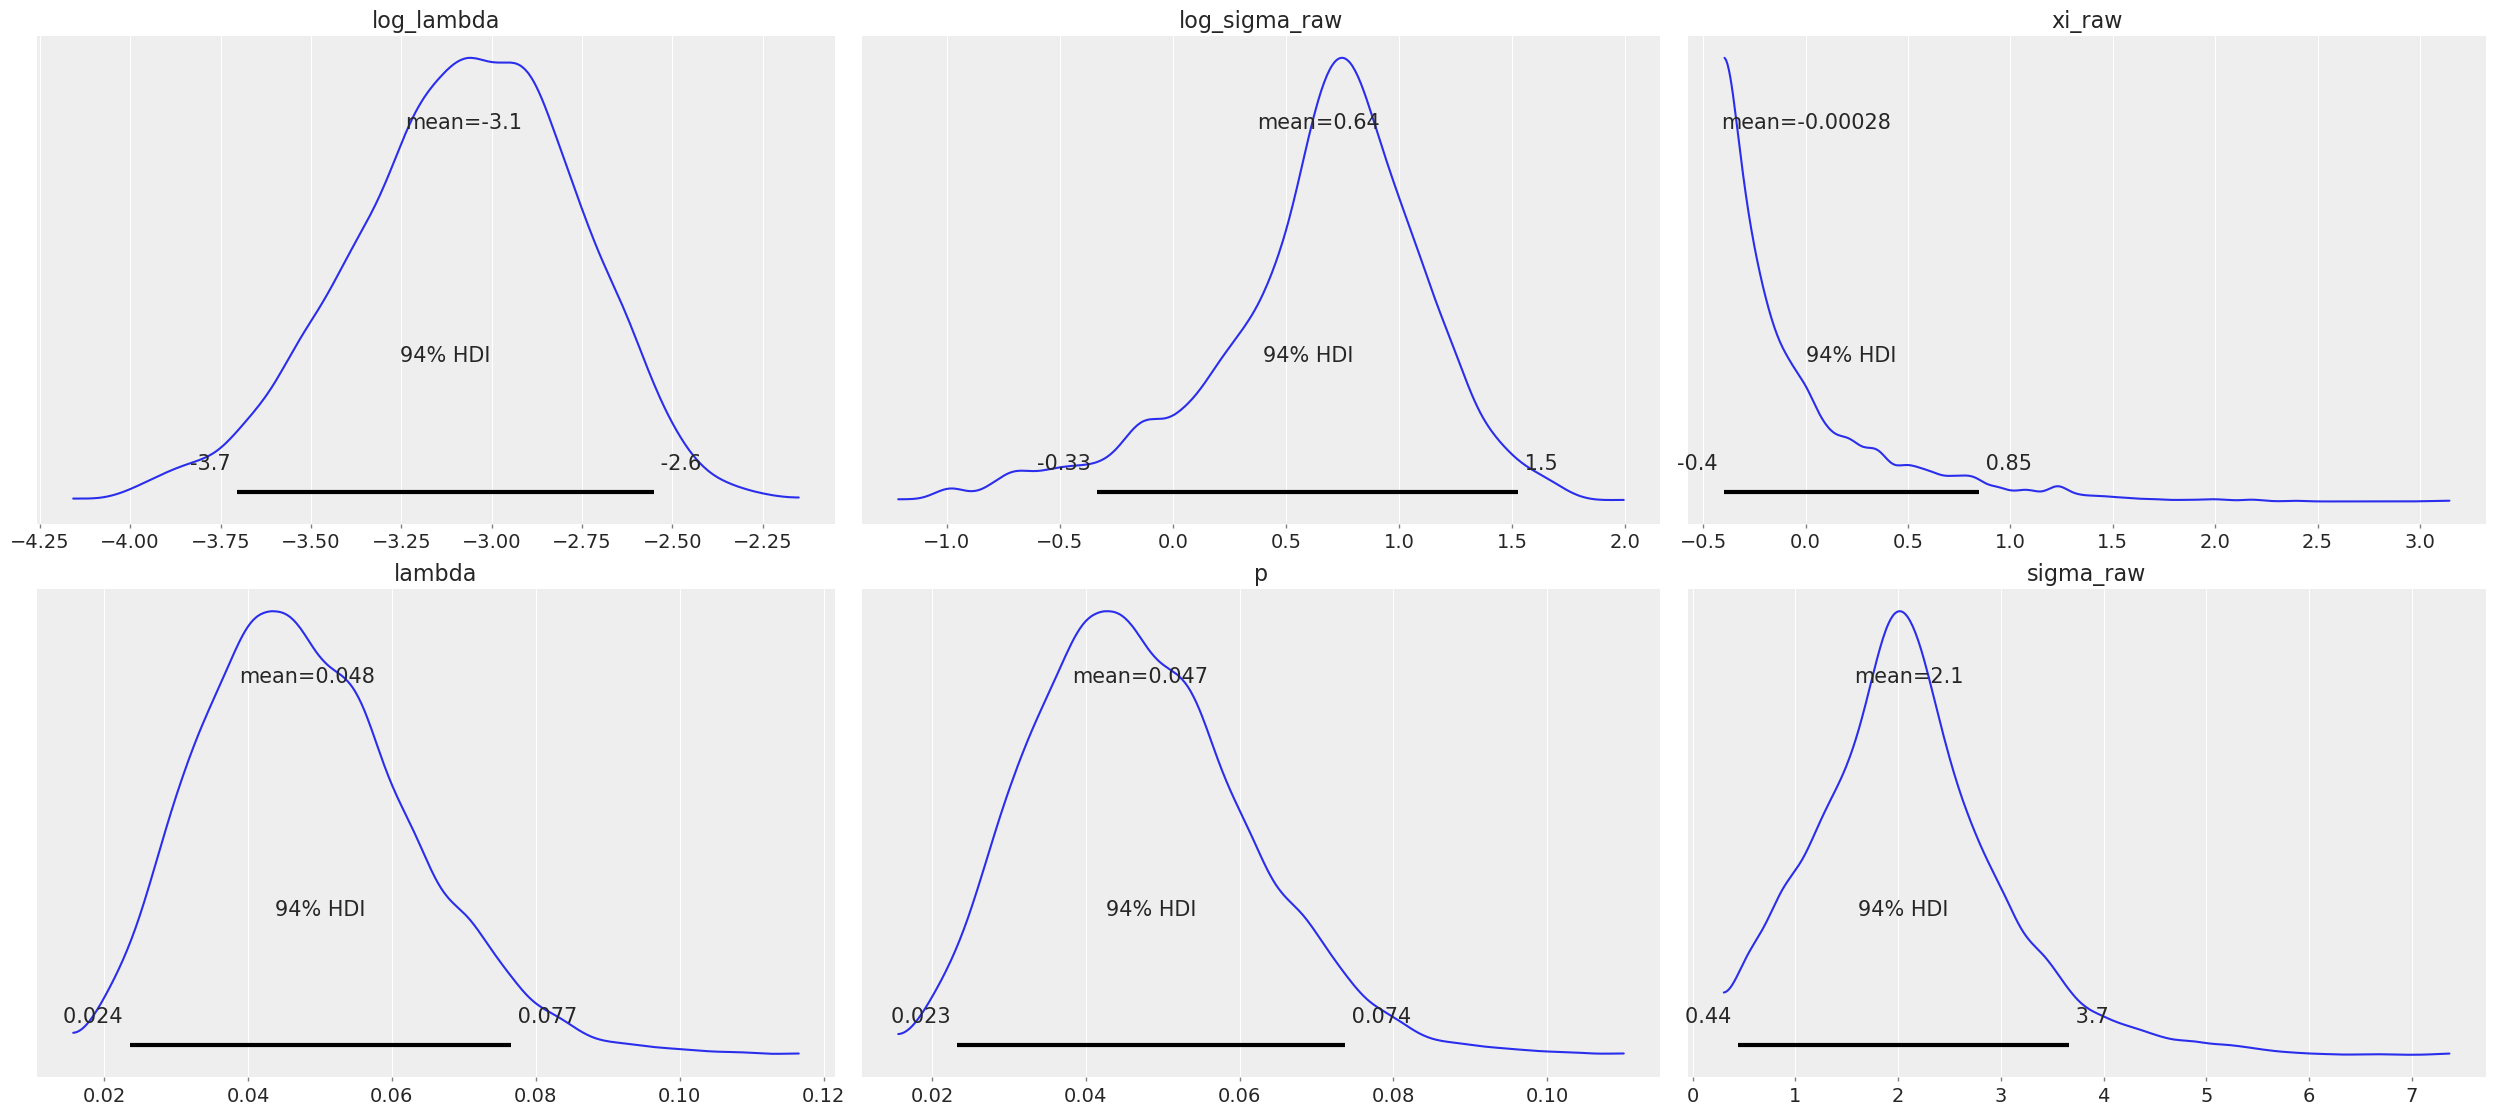

In [40]:
az.plot_posterior(idata)

array([[<Axes: title={'center': 'log_lambda'}>,
        <Axes: title={'center': 'log_lambda'}>],
       [<Axes: title={'center': 'log_sigma_raw'}>,
        <Axes: title={'center': 'log_sigma_raw'}>],
       [<Axes: title={'center': 'xi_raw'}>,
        <Axes: title={'center': 'xi_raw'}>],
       [<Axes: title={'center': 'lambda'}>,
        <Axes: title={'center': 'lambda'}>],
       [<Axes: title={'center': 'p'}>, <Axes: title={'center': 'p'}>],
       [<Axes: title={'center': 'sigma_raw'}>,
        <Axes: title={'center': 'sigma_raw'}>]], dtype=object)

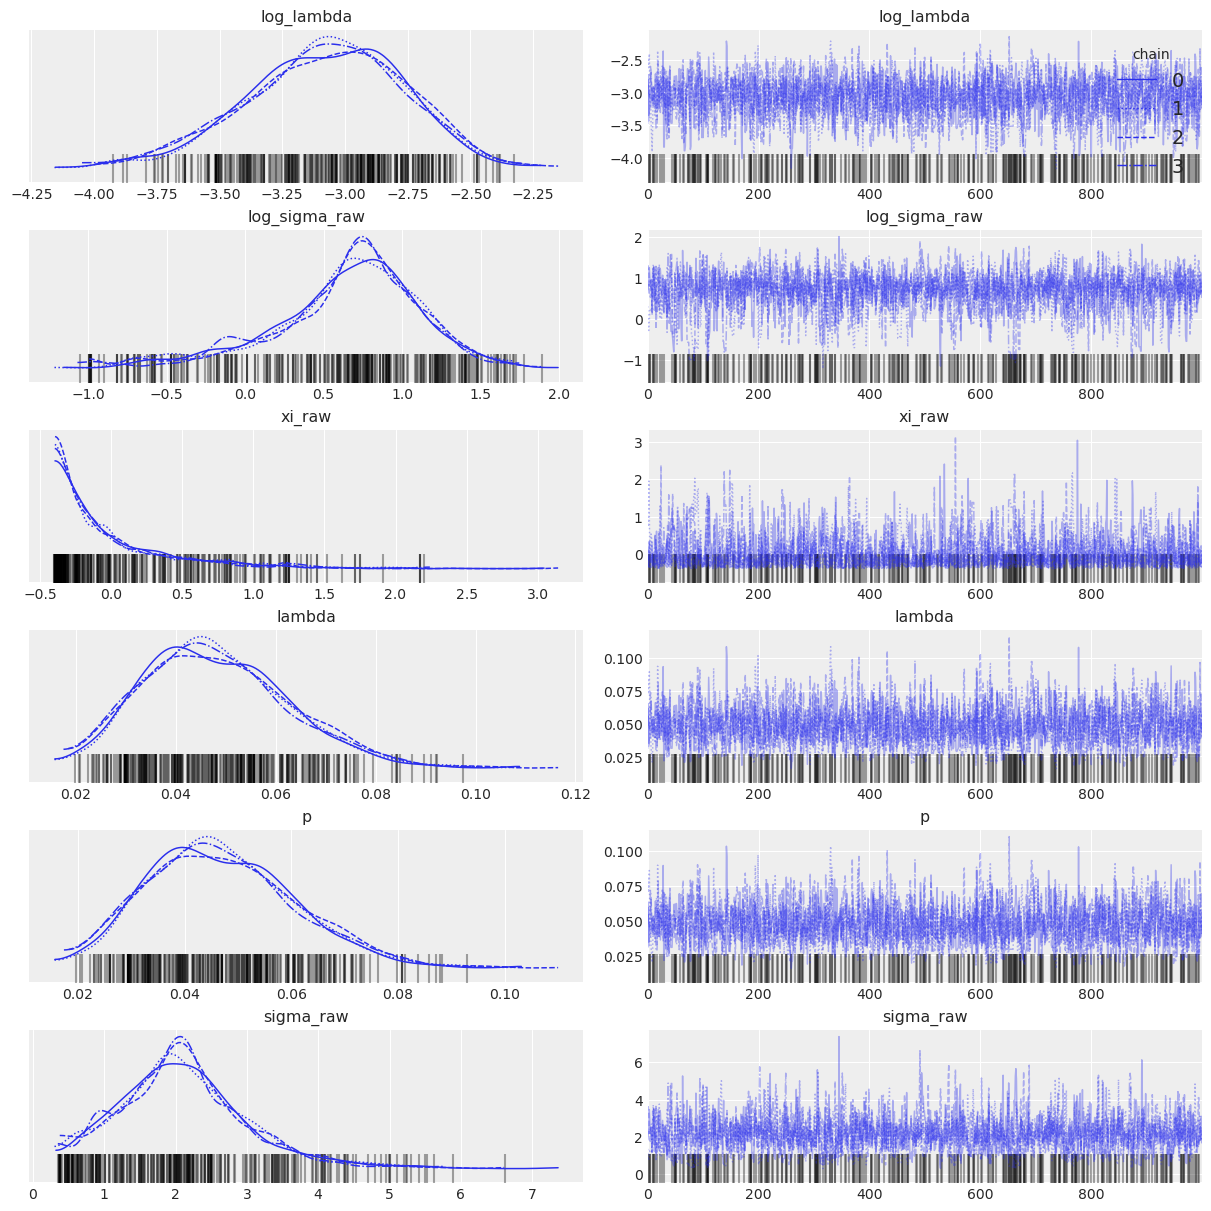

In [41]:
az.plot_trace(idata, legend=True)

In [ ]:
from matplotlib.lines import Line2D

In [66]:
# Add prior distribution for p
prior_lambda = np.exp(prior['log_lambda'].values)
prior_p = (1 - np.exp(-prior_lambda)).flatten()

# Add prior distribution for sigma
prior_sigma = np.exp(prior['log_sigma_raw'].values).flatten()
ax2.violinplot([prior_sigma], [-0.5], points=100, widths=0.5)

# Add prior distribution for xi
prior_xi = prior['xi_raw'].values.flatten()

C:\Users\squaade\AppData\Local\Temp\ipykernel_33576\2560042349.py:67: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


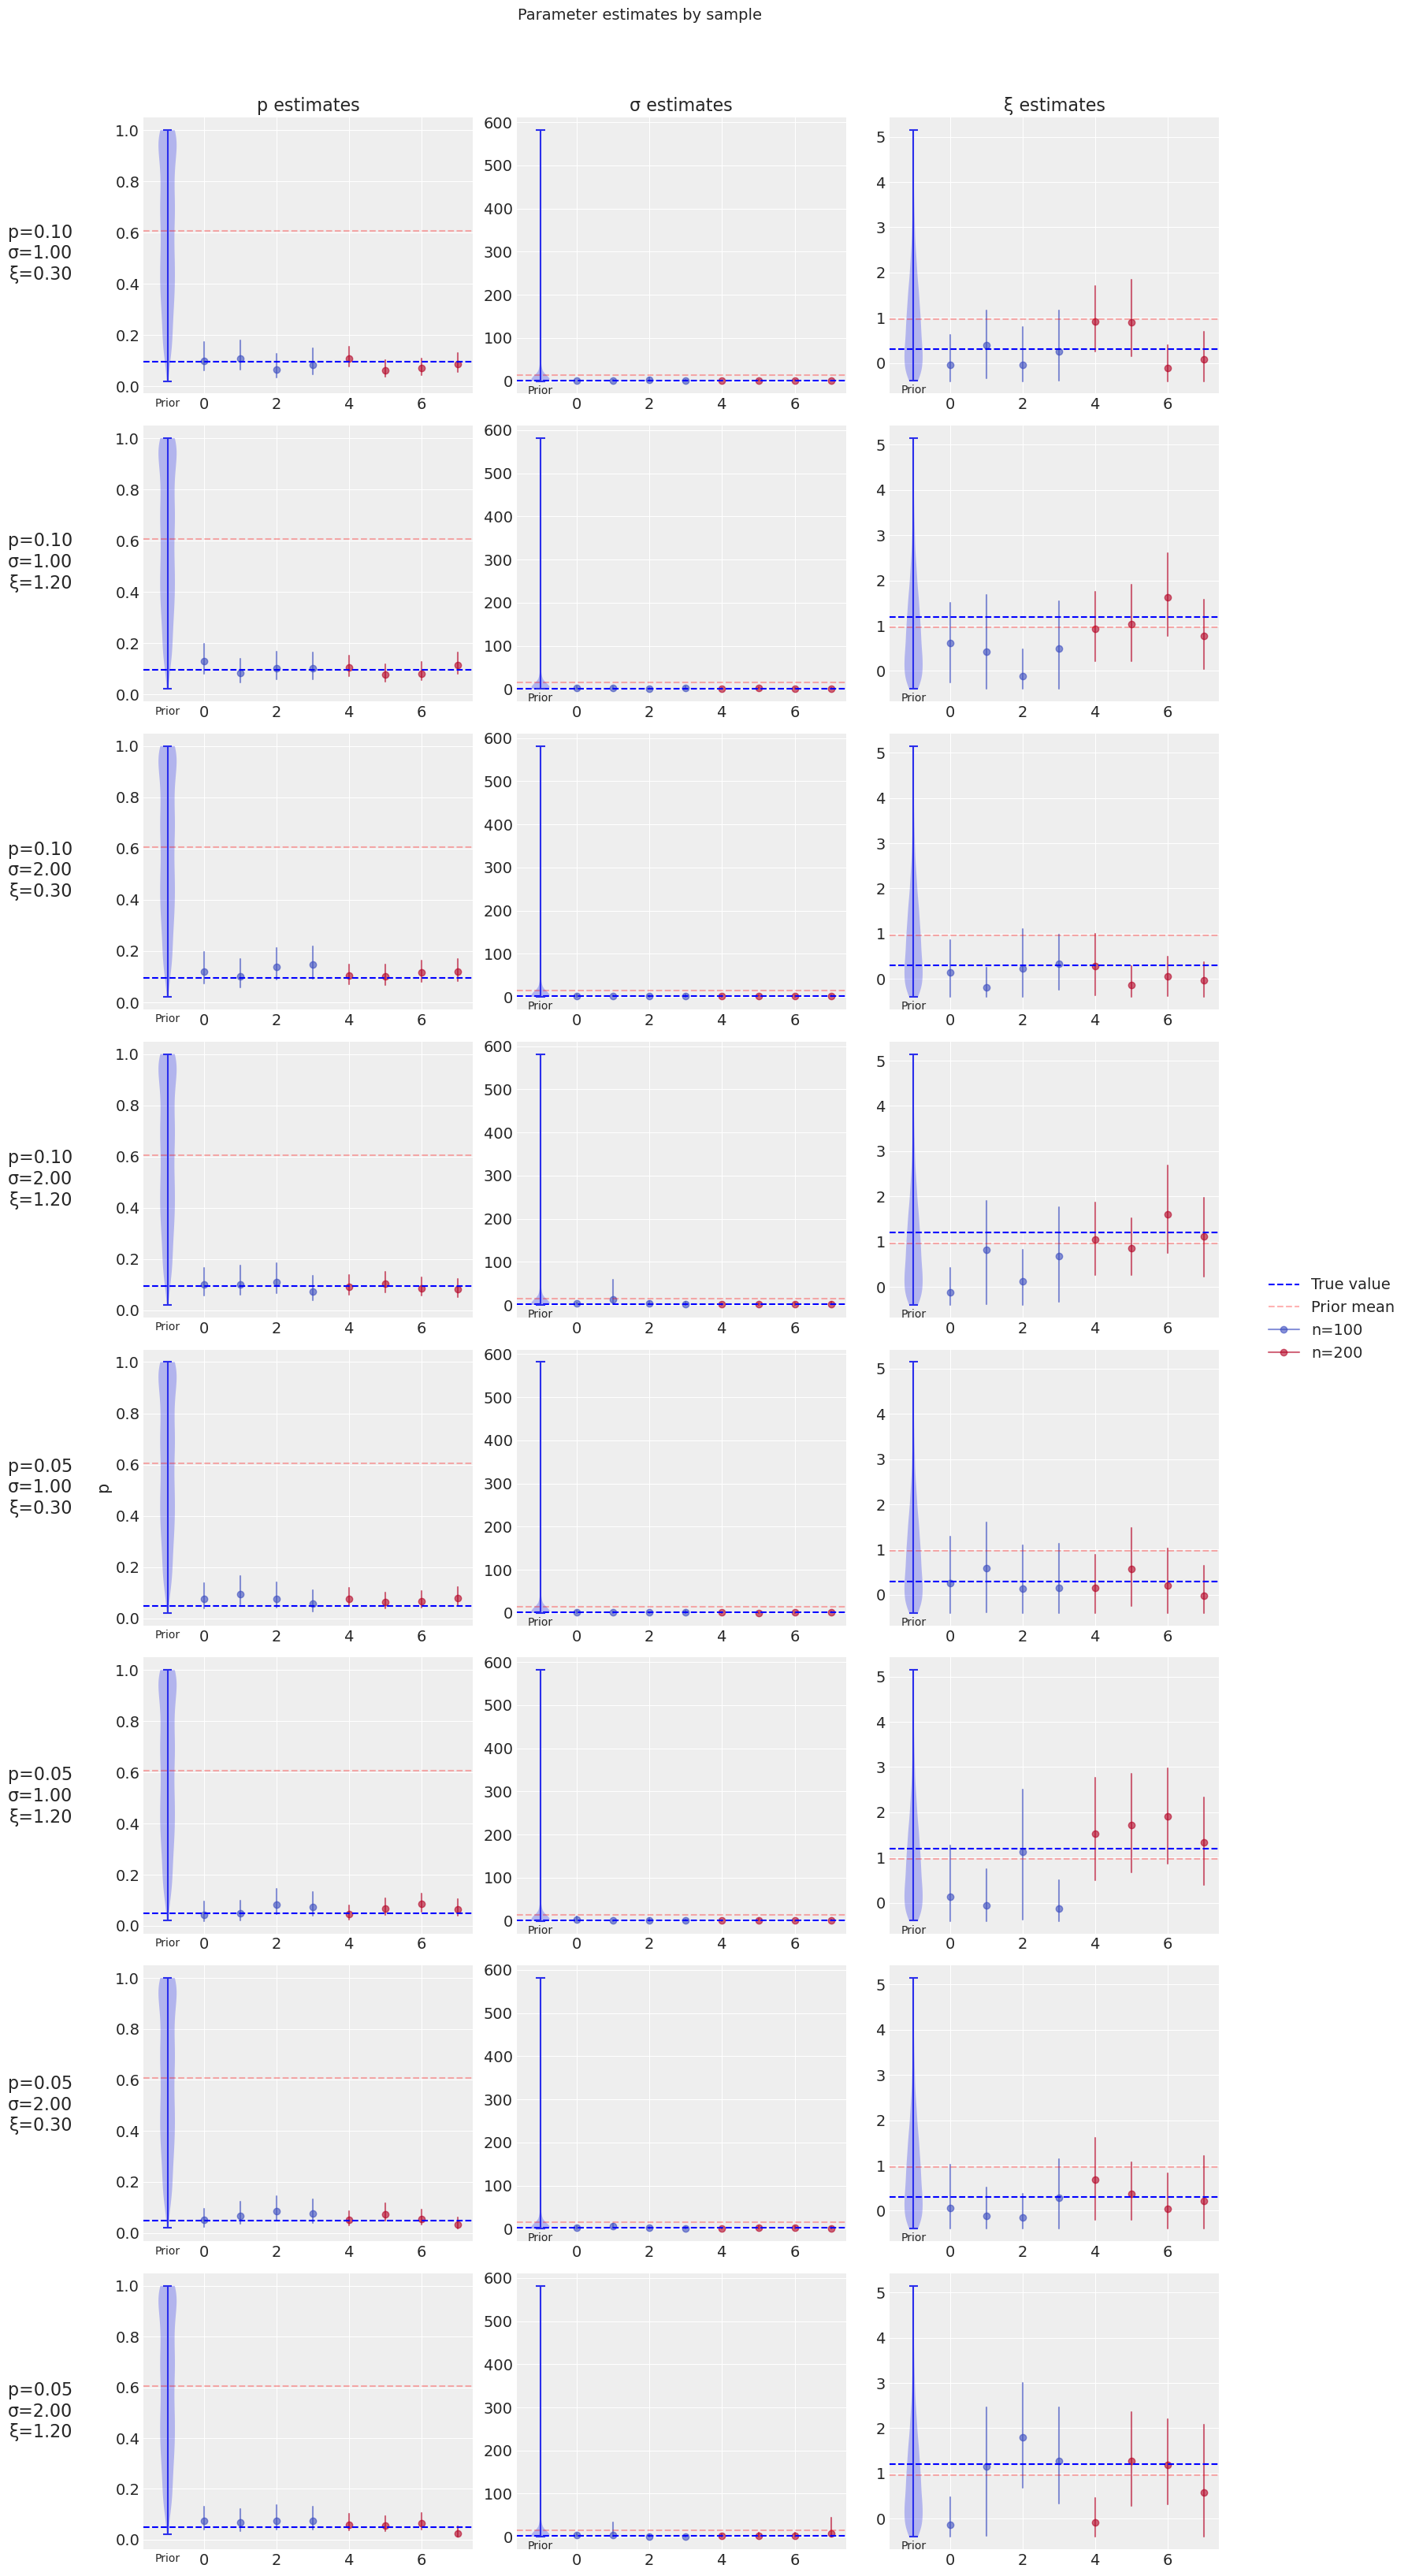

In [72]:
# Create figure with subplots for each parameter combination and parameter
param_combos = df[['p_true', 'sigma_true', 'xi_true']].drop_duplicates()
n_combos = len(param_combos)

# Create a grid of subplots - one row per parameter combo, one column per parameter
fig, axes = plt.subplots(n_combos, 3, figsize=(15, 4*n_combos))
fig.suptitle('Parameter estimates by sample', fontsize=14, y=1.02)

# Column titles
axes[0,0].set_title('p estimates')
axes[0,1].set_title('σ estimates') 
axes[0,2].set_title('ξ estimates')

# Get unique sample sizes and create colormap
sample_sizes = sorted(df['sample_ns'].unique())
colors = plt.cm.coolwarm(np.linspace(0, 1, len(sample_sizes)))
color_dict = dict(zip(sample_sizes, colors))

# Plot each parameter combination
for i, (_, combo) in enumerate(param_combos.iterrows()):
    # Get data for this parameter combination
    mask = ((df['p_true'] == combo['p_true']) & 
            (df['sigma_true'] == combo['sigma_true']) & 
            (df['xi_true'] == combo['xi_true']))
    subset = df[mask].sort_values('sample_ns')  # Sort by sample size
    
    # Create row label with true parameter values
    row_label = f'p={combo["p_true"]:.2f}\nσ={combo["sigma_true"]:.2f}\nξ={combo["xi_true"]:.2f}'
    
    # Plot p estimates
    for j, (idx, row) in enumerate(subset.iterrows()):
        color = color_dict[row['sample_ns']]
        axes[i,0].plot([j, j], [row['p_hdi_l'], row['p_hdi_u']], '-', color=color, alpha=0.6)
        axes[i,0].plot(j, row['p_hat'], 'o', color=color, alpha=0.6)
    axes[i,0].axhline(y=combo['p_true'], color='b', linestyle='--')
    axes[i,0].axhline(y=prior_p.mean(), color='r', linestyle='--', alpha=0.3)
    axes[i,0].set_ylabel('p' if i == len(param_combos)//2 else '')
    # Add prior violin plot for p
    axes[i,0].violinplot([prior_p], [-1], points=100, widths=0.5)
    axes[i,0].text(-1, axes[i,0].get_ylim()[0] - 0.05, 'Prior', ha='center')

    # Plot sigma estimates  
    for j, (idx, row) in enumerate(subset.iterrows()):
        color = color_dict[row['sample_ns']]
        axes[i,1].plot([j, j], [row['sigma_hdi_l'], row['sigma_hdi_u']], '-', color=color, alpha=0.6)
        axes[i,1].plot(j, row['sigma_hat'], 'o', color=color, alpha=0.6)
    axes[i,1].axhline(y=combo['sigma_true'], color='b', linestyle='--')
    axes[i,1].axhline(y=prior_sigma.mean(), color='r', linestyle='--', alpha=0.3)
    axes[i,1].set_ylabel('')
    # Add prior violin plot for sigma
    axes[i,1].violinplot([prior_sigma], [-1], points=100, widths=0.5)
    axes[i,1].text(-1, axes[i,1].get_ylim()[0] - 0.05, 'Prior', ha='center')
    
    # Plot xi estimates
    for j, (idx, row) in enumerate(subset.iterrows()):
        color = color_dict[row['sample_ns']]
        axes[i,2].plot([j, j], [row['xi_hdi_l'], row['xi_hdi_u']], '-', color=color, alpha=0.6)
        axes[i,2].plot(j, row['xi_hat'], 'o', color=color, alpha=0.6)
    axes[i,2].axhline(y=combo['xi_true'], color='b', linestyle='--')
    axes[i,2].axhline(y=prior_xi.mean(), color='r', linestyle='--', alpha=0.3)
    axes[i,2].set_ylabel('')
    # Add prior violin plot for xi
    axes[i,2].violinplot([prior_xi], [-1], points=100, widths=0.5)
    axes[i,2].text(-1, axes[i,2].get_ylim()[0], 'Prior', ha='center')

    # Adjust layout first to get final subplot positions
    plt.tight_layout()
    plt.subplots_adjust(left=0.08)  # Increased left margin for labels
    
    # Add row label to the left of the first subplot after layout is set
    fig.text(0.02, axes[i,0].get_position().y0 + axes[i,0].get_position().height/2,
             row_label, rotation=0, ha='right', va='center', fontsize=16)

# Add legend
lines = [Line2D([0], [0], color='b', linestyle='--', label='True value'),
         Line2D([0], [0], color='r', linestyle='--', alpha=0.3, label='Prior mean')]

# Add sample size lines to legend
for n in sample_sizes:
    lines.append(Line2D([0], [0], color=color_dict[n], marker='o', linestyle='-', 
                       alpha=0.6, label=f'n={n}'))

fig.legend(handles=lines, bbox_to_anchor=(1.02, 0.5), loc='center left')

C:\Users\squaade\AppData\Local\Temp\ipykernel_33576\602871928.py:67: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


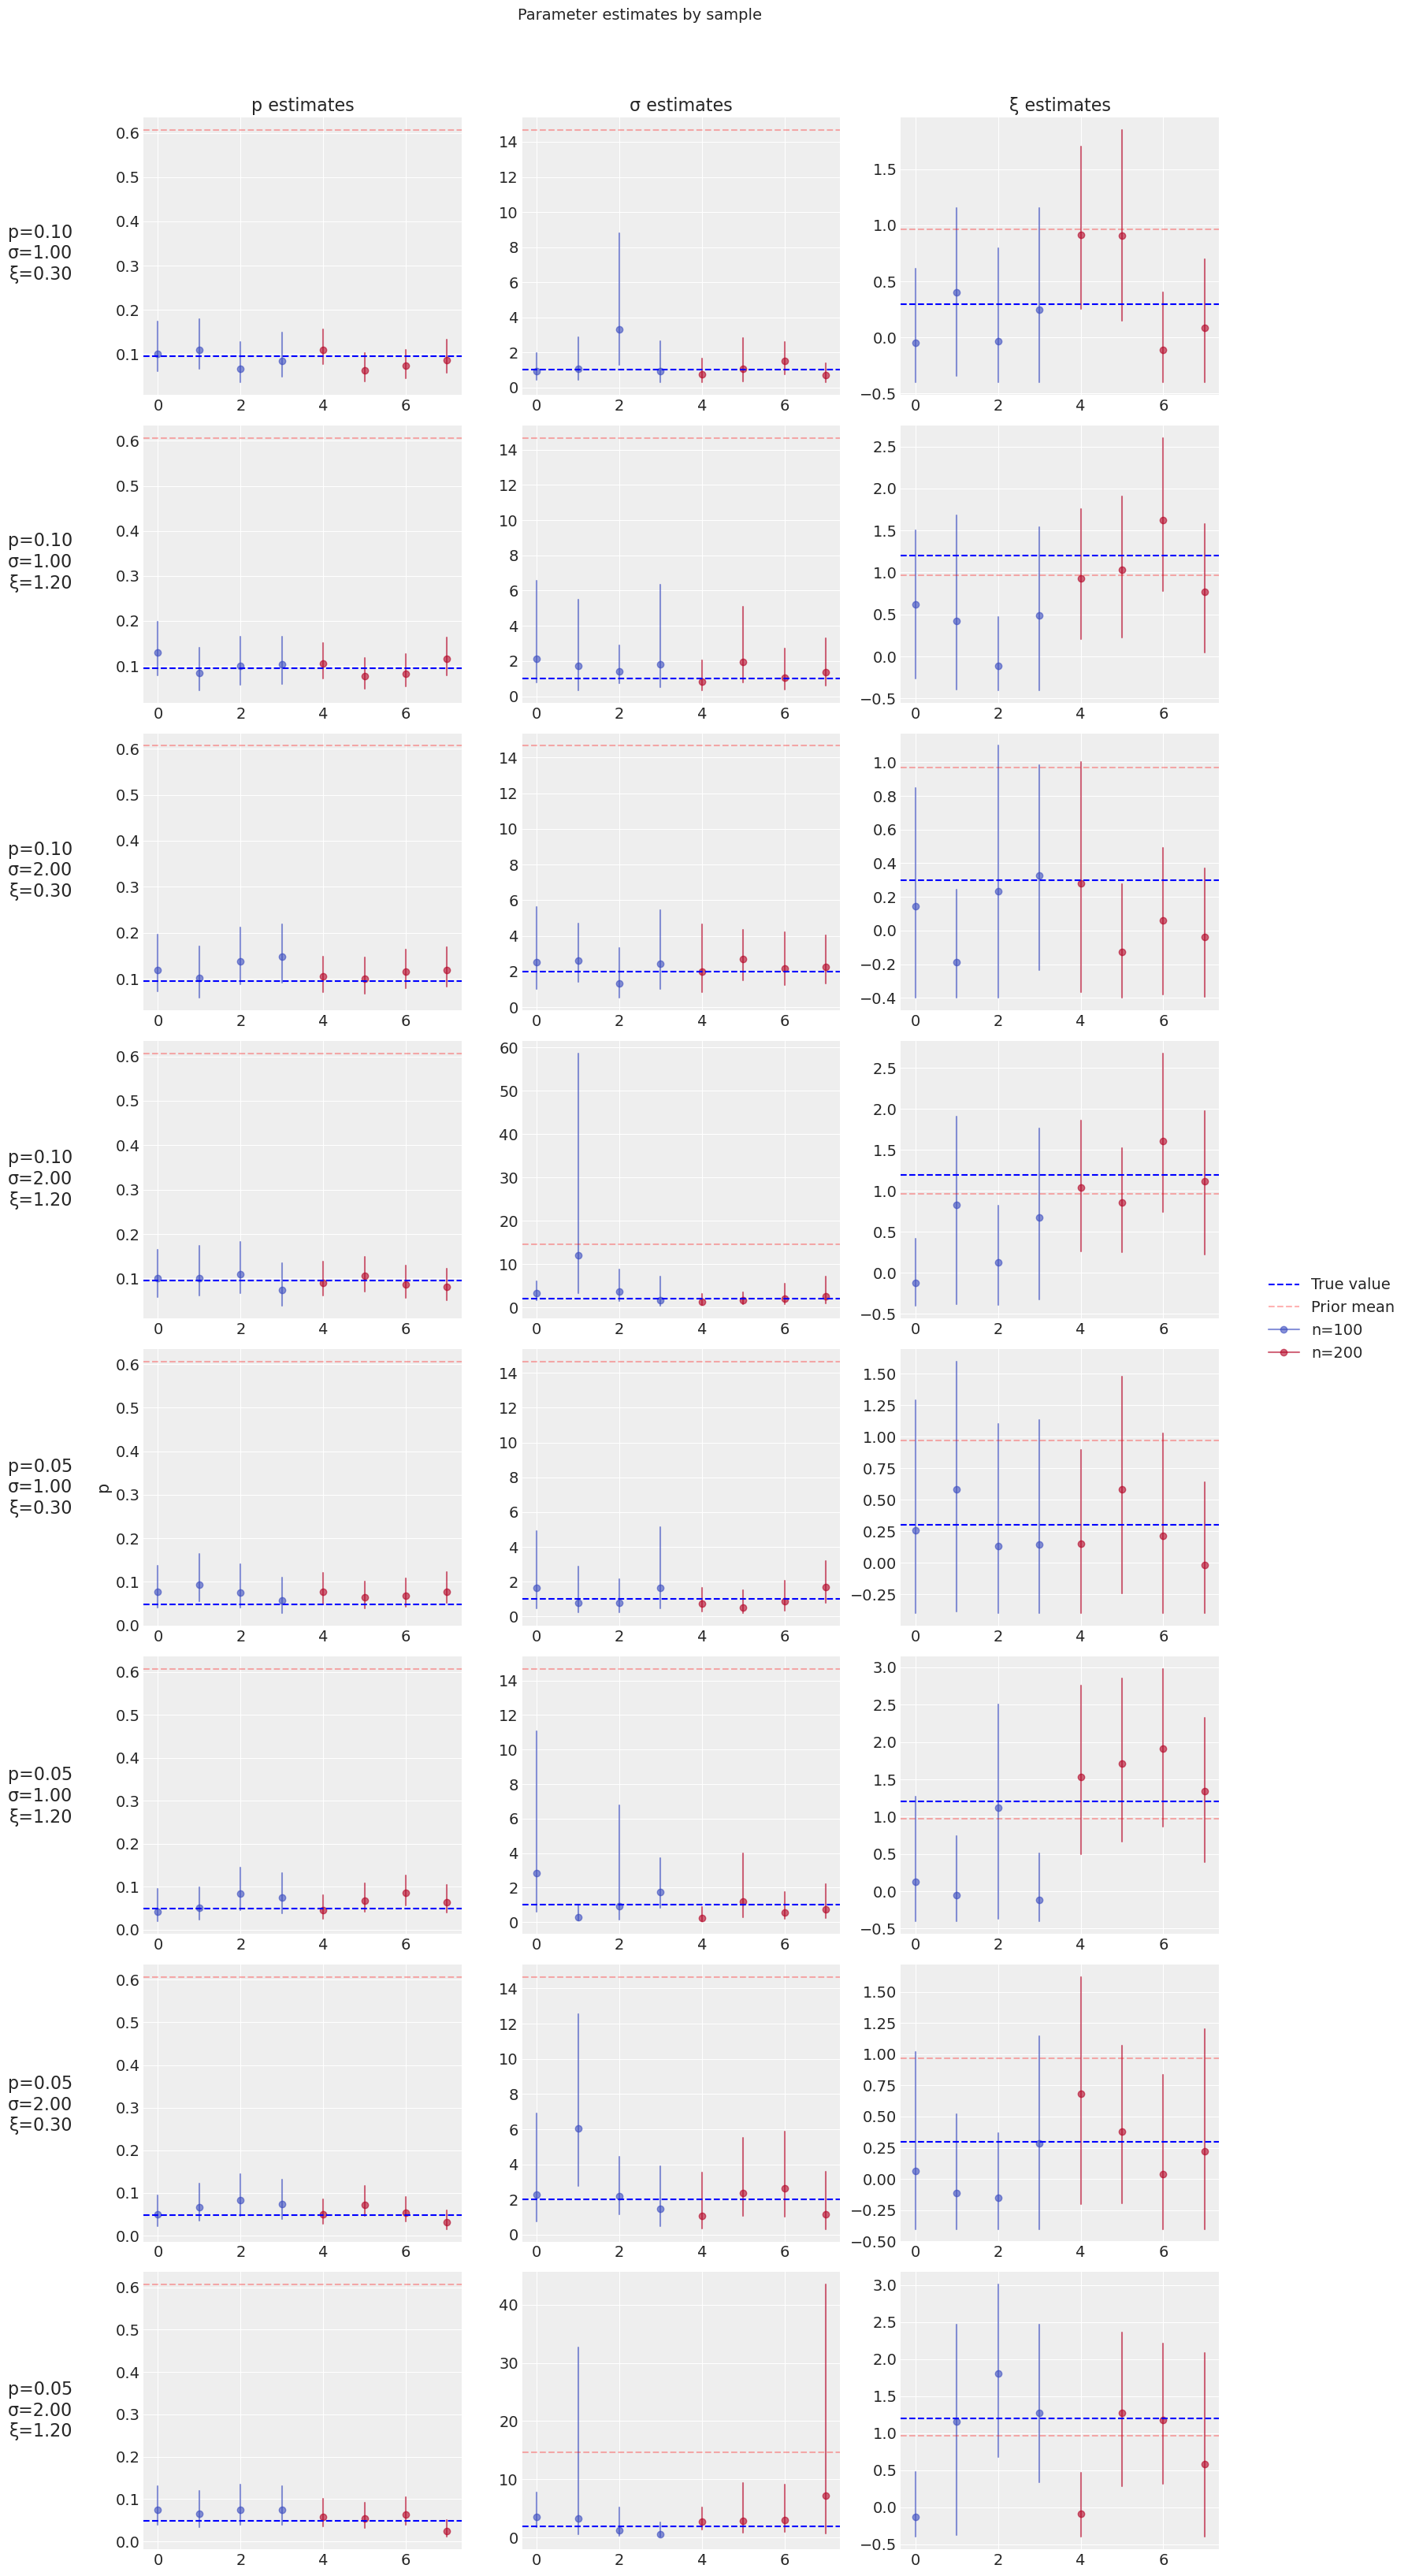

In [73]:
# Create figure with subplots for each parameter combination and parameter
param_combos = df[['p_true', 'sigma_true', 'xi_true']].drop_duplicates()
n_combos = len(param_combos)

# Create a grid of subplots - one row per parameter combo, one column per parameter
fig, axes = plt.subplots(n_combos, 3, figsize=(15, 4*n_combos))
fig.suptitle('Parameter estimates by sample', fontsize=14, y=1.02)

# Column titles
axes[0,0].set_title('p estimates')
axes[0,1].set_title('σ estimates') 
axes[0,2].set_title('ξ estimates')

# Get unique sample sizes and create colormap
sample_sizes = sorted(df['sample_ns'].unique())
colors = plt.cm.coolwarm(np.linspace(0, 1, len(sample_sizes)))
color_dict = dict(zip(sample_sizes, colors))

# Plot each parameter combination
for i, (_, combo) in enumerate(param_combos.iterrows()):
    # Get data for this parameter combination
    mask = ((df['p_true'] == combo['p_true']) & 
            (df['sigma_true'] == combo['sigma_true']) & 
            (df['xi_true'] == combo['xi_true']))
    subset = df[mask].sort_values('sample_ns')  # Sort by sample size
    
    # Create row label with true parameter values
    row_label = f'p={combo["p_true"]:.2f}\nσ={combo["sigma_true"]:.2f}\nξ={combo["xi_true"]:.2f}'
    
    # Plot p estimates
    for j, (idx, row) in enumerate(subset.iterrows()):
        color = color_dict[row['sample_ns']]
        axes[i,0].plot([j, j], [row['p_hdi_l'], row['p_hdi_u']], '-', color=color, alpha=0.6)
        axes[i,0].plot(j, row['p_hat'], 'o', color=color, alpha=0.6)
    axes[i,0].axhline(y=combo['p_true'], color='b', linestyle='--')
    axes[i,0].axhline(y=prior_p.mean(), color='r', linestyle='--', alpha=0.3)
    axes[i,0].set_ylabel('p' if i == len(param_combos)//2 else '')
    # Add prior violin plot for p
    # axes[i,0].violinplot([prior_p], [-1], points=100, widths=0.5)
    # axes[i,0].text(-1, axes[i,0].get_ylim()[0] - 0.05, 'Prior', ha='center')

    # Plot sigma estimates  
    for j, (idx, row) in enumerate(subset.iterrows()):
        color = color_dict[row['sample_ns']]
        axes[i,1].plot([j, j], [row['sigma_hdi_l'], row['sigma_hdi_u']], '-', color=color, alpha=0.6)
        axes[i,1].plot(j, row['sigma_hat'], 'o', color=color, alpha=0.6)
    axes[i,1].axhline(y=combo['sigma_true'], color='b', linestyle='--')
    axes[i,1].axhline(y=prior_sigma.mean(), color='r', linestyle='--', alpha=0.3)
    axes[i,1].set_ylabel('')
    # Add prior violin plot for sigma
    # axes[i,1].violinplot([prior_sigma], [-1], points=100, widths=0.5)
    # axes[i,1].text(-1, axes[i,1].get_ylim()[0] - 0.05, 'Prior', ha='center')
    
    # Plot xi estimates
    for j, (idx, row) in enumerate(subset.iterrows()):
        color = color_dict[row['sample_ns']]
        axes[i,2].plot([j, j], [row['xi_hdi_l'], row['xi_hdi_u']], '-', color=color, alpha=0.6)
        axes[i,2].plot(j, row['xi_hat'], 'o', color=color, alpha=0.6)
    axes[i,2].axhline(y=combo['xi_true'], color='b', linestyle='--')
    axes[i,2].axhline(y=prior_xi.mean(), color='r', linestyle='--', alpha=0.3)
    axes[i,2].set_ylabel('')
    # Add prior violin plot for xi
    # axes[i,2].violinplot([prior_xi], [-1], points=100, widths=0.5)
    # axes[i,2].text(-1, axes[i,2].get_ylim()[0], 'Prior', ha='center')

    # Adjust layout first to get final subplot positions
    plt.tight_layout()
    plt.subplots_adjust(left=0.08)  # Increased left margin for labels
    
    # Add row label to the left of the first subplot after layout is set
    fig.text(0.02, axes[i,0].get_position().y0 + axes[i,0].get_position().height/2,
             row_label, rotation=0, ha='right', va='center', fontsize=16)

# Add legend
lines = [Line2D([0], [0], color='b', linestyle='--', label='True value'),
         Line2D([0], [0], color='r', linestyle='--', alpha=0.3, label='Prior mean')]

# Add sample size lines to legend
for n in sample_sizes:
    lines.append(Line2D([0], [0], color=color_dict[n], marker='o', linestyle='-', 
                       alpha=0.6, label=f'n={n}'))

fig.legend(handles=lines, bbox_to_anchor=(1.02, 0.5), loc='center left')

array([[<Axes: title={'center': 'log_lambda'}>,
        <Axes: title={'center': 'log_lambda'}>],
       [<Axes: title={'center': 'log_sigma_raw'}>,
        <Axes: title={'center': 'log_sigma_raw'}>],
       [<Axes: title={'center': 'xi_raw'}>,
        <Axes: title={'center': 'xi_raw'}>],
       [<Axes: title={'center': 'lambda'}>,
        <Axes: title={'center': 'lambda'}>],
       [<Axes: title={'center': 'p'}>, <Axes: title={'center': 'p'}>],
       [<Axes: title={'center': 'sigma_raw'}>,
        <Axes: title={'center': 'sigma_raw'}>]], dtype=object)

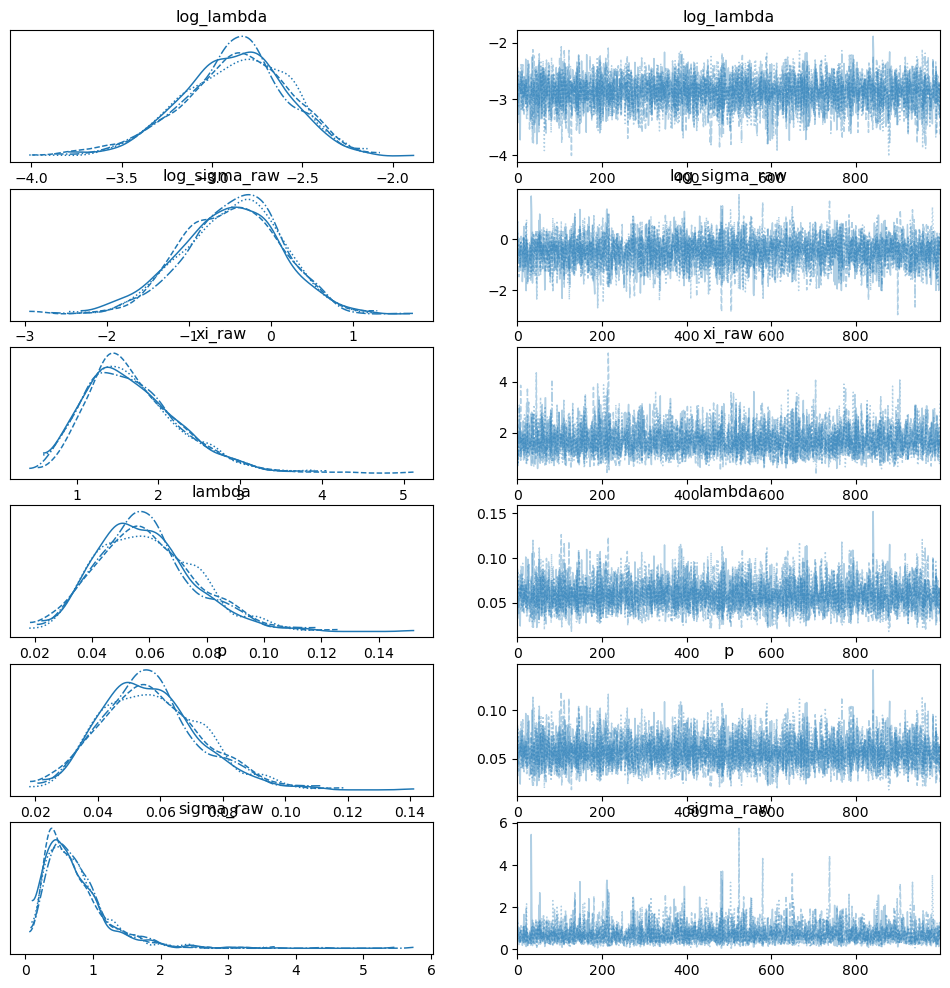

In [49]:
az.plot_trace(idata)

In [ ]:
az.plot_posterior()